# Datathon FIAP — Associação Passos Mágicos

## 1.Contexto do projeto

A Associação Passos Mágicos atua no desenvolvimento educacional de crianças e jovens em situação de vulnerabilidade social. A partir dos dados da Pesquisa Extensiva do Desenvolvimento Educacional (PEDE), este projeto analisa os indicadores acadêmicos, psicossociais e de engajamento dos alunos entre 2022 e 2024.

O objetivo da análise é identificar padrões de desempenho, evolução educacional e fatores associados ao risco de defasagem, utilizando técnicas de análise exploratória de dados e Machine Learning.

## 2.Objetivos analíticos

O projeto está estruturado em três frentes principais:

- análise evolutiva dos indicadores educacionais;
- resposta às perguntas de negócio propostas no Datathon;
- desenvolvimento de modelo preditivo para identificação antecipada de risco educacional.

## 3.Configuração do ambiente

Importação das bibliotecas utilizadas para manipulação dos dados, análise exploratória, visualização e modelagem preditiva.

In [1]:
# Manipulação de dados
import pandas as pd
import numpy as np

# Visualização
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

# Configurações gerais
pd.set_option("display.max_columns", 80)
pd.set_option("display.float_format", "{:.2f}".format)

plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.grid"] = True

import warnings
warnings.filterwarnings("ignore")

print("Ambiente configurado com sucesso.")

Ambiente configurado com sucesso.


## 4.Leitura e inspeção inicial da base

A base de dados do PEDE está organizada em abas independentes para os ciclos de 2022, 2023 e 2024. Nesta etapa será realizada a leitura estrutural do arquivo, validação das abas disponíveis e inspeção inicial das diferenças entre os conjuntos de dados.

In [2]:
from google.colab import files

uploaded = files.upload()

arquivo_base = list(uploaded.keys())[0]

print(f"Arquivo carregado: {arquivo_base}")

Saving BASE DE DADOS PEDE 2024 - DATATHON.xlsx to BASE DE DADOS PEDE 2024 - DATATHON.xlsx
Arquivo carregado: BASE DE DADOS PEDE 2024 - DATATHON.xlsx


In [3]:
excel = pd.ExcelFile(arquivo_base)

print("Abas encontradas:")

for aba in excel.sheet_names:
    print(f"- {aba}")

Abas encontradas:
- PEDE2022
- PEDE2023
- PEDE2024


### 4.1 Leitura das bases por ano

Após a validação do arquivo, as abas referentes aos ciclos de 2022, 2023 e 2024 são carregadas separadamente para inspeção estrutural das variáveis e preparação da etapa de consolidação longitudinal.

In [4]:
df_22 = pd.read_excel(arquivo_base, sheet_name="PEDE2022")
df_23 = pd.read_excel(arquivo_base, sheet_name="PEDE2023")
df_24 = pd.read_excel(arquivo_base, sheet_name="PEDE2024")

print(f"Dimensões 2022: {df_22.shape}")
print(f"Dimensões 2023: {df_23.shape}")
print(f"Dimensões 2024: {df_24.shape}")

Dimensões 2022: (860, 42)
Dimensões 2023: (1014, 48)
Dimensões 2024: (1156, 50)


### 4.2 Inspeção das divergências estruturais

Os ciclos apresentam diferenças de nomenclatura e composição das variáveis. A identificação dessas divergências é necessária para padronização dos indicadores e consolidação da base analítica.

In [5]:
cols_22 = set(df_22.columns)
cols_23 = set(df_23.columns)
cols_24 = set(df_24.columns)

print("--- Análise de Divergência de Colunas ---\n")

print(f"Exclusivas em 2022: {cols_22 - cols_23 - cols_24}")
print()

print(f"Exclusivas em 2023: {cols_23 - cols_22 - cols_24}")
print()

print(f"Exclusivas em 2024: {cols_24 - cols_22 - cols_23}")

--- Análise de Divergência de Colunas ---

Exclusivas em 2022: {'Portug', 'Defas', 'Matem', 'Inglês', 'Idade 22', 'Fase ideal', 'Nome', 'Ano nasc'}

Exclusivas em 2023: {'Pedra 2023', 'INDE 2023', 'Destaque IPV.1'}

Exclusivas em 2024: {'Pedra 2024', 'Escola', 'INDE 2024', 'Avaliador6', 'Ativo/ Inativo.1', 'Avaliador5', 'Ativo/ Inativo'}


## 5.ETL e padronização dos dados

Após a inspeção estrutural das bases, inicia-se a etapa de transformação e consolidação dos dados. O objetivo é padronizar os indicadores entre os ciclos, reduzir inconsistências de nomenclatura e construir uma base longitudinal única para análise.

### 5.1 Padronização das variáveis

As bases apresentam diferenças de nomenclatura entre variáveis equivalentes ao longo dos anos. Nesta etapa são realizados os ajustes necessários para uniformizar os indicadores e permitir a consolidação analítica dos dados.

In [6]:
rename_22 = {
    "Nome": "NOME",
    "Ano nasc": "DATA_NASC",
    "Idade 22": "IDADE",
    "Matem": "MAT",
    "Portug": "PORT",
    "Inglês": "ING",
    "Fase ideal": "FASE_IDEAL",
    "Defas": "DEFASAGEM",
    "Pedra 22": "PEDRA",
    "INDE 22": "INDE"
}

rename_23 = {
    "Nome Anonimizado": "NOME",
    "Data de Nasc": "DATA_NASC",
    "Mat": "MAT",
    "Por": "PORT",
    "Ing": "ING",
    "Fase Ideal": "FASE_IDEAL",
    "Pedra 2023": "PEDRA",
    "INDE 2023": "INDE"
}

rename_24 = {
    "Nome Anonimizado": "NOME",
    "Data de Nasc": "DATA_NASC",
    "Mat": "MAT",
    "Por": "PORT",
    "Ing": "ING",
    "Fase Ideal": "FASE_IDEAL",
    "Pedra 2024": "PEDRA",
    "INDE 2024": "INDE"
}

df_22.rename(columns=rename_22, inplace=True)
df_23.rename(columns=rename_23, inplace=True)
df_24.rename(columns=rename_24, inplace=True)

df_22["ANO"] = 2022
df_23["ANO"] = 2023
df_24["ANO"] = 2024

print("Padronização concluída.")

Padronização concluída.


### 5.2 Consolidação longitudinal da base

Com as variáveis padronizadas, os ciclos de 2022, 2023 e 2024 podem ser integrados em uma única estrutura analítica. A consolidação longitudinal permitirá acompanhar o comportamento dos indicadores ao longo do tempo e construir análises comparativas entre os anos.

In [7]:
colunas_comuns = sorted(
    set(df_22.columns)
    & set(df_23.columns)
    & set(df_24.columns)
)

df = pd.concat([
    df_22[colunas_comuns],
    df_23[colunas_comuns],
    df_24[colunas_comuns]
], ignore_index=True)

print(f"Dimensões da base consolidada: {df.shape}\n")

print("Registros por ano:")
print(df["ANO"].value_counts().sort_index())

Dimensões da base consolidada: (3030, 39)

Registros por ano:
ANO
2022     860
2023    1014
2024    1156
Name: count, dtype: int64


In [8]:
df_22["IPP"] = np.nan

colunas_comuns = list(
    set(df_22.columns)
    & set(df_23.columns)
    & set(df_24.columns)
)

df = pd.concat(
    [
        df_22[colunas_comuns],
        df_23[colunas_comuns],
        df_24[colunas_comuns]
    ],
    ignore_index=True
)

df = df.sort_values(
    by=["ANO", "RA"]
).reset_index(drop=True)

print(f"Dimensões da base consolidada: {df.shape}\n")

print("Registros por ano:")
print(
    df["ANO"]
    .value_counts()
    .sort_index()
)

print("\nIPP na base consolidada:")
print(
    df.groupby("ANO")["IPP"]
    .apply(lambda x: x.notna().sum())
)

Dimensões da base consolidada: (3030, 40)

Registros por ano:
ANO
2022     860
2023    1014
2024    1156
Name: count, dtype: int64

IPP na base consolidada:
ANO
2022       0
2023     938
2024    1054
Name: IPP, dtype: int64


### 5.3 Validação estrutural da base consolidada

Após a consolidação, a estrutura da base é validada para identificar possíveis inconsistências de tipos, valores ausentes e categorias divergentes que possam impactar as análises estatísticas e o modelo preditivo.

In [9]:
print("--- Tipos de Dados da Base Consolidada ---\n")

tipos = df.dtypes.astype(str).value_counts()

for tipo, quantidade in tipos.items():
    print(f"{tipo:<10}: {quantidade} colunas")

--- Tipos de Dados da Base Consolidada ---

object    : 24 colunas
float64   : 14 colunas
int64     : 2 colunas


### 5.4 Análise de valores ausentes

A consolidação longitudinal introduz lacunas decorrentes de diferenças estruturais entre os ciclos do PEDE. Nesta etapa são identificados os campos com maior volumetria de valores ausentes para definição da estratégia de tratamento da base analítica.

In [10]:
nulos = (
    df.isnull()
    .sum()
    .sort_values(ascending=False)
)

nulos = nulos[nulos > 0]

print("--- Colunas com Valores Ausentes ---\n")

for coluna, quantidade in nulos.items():
    percentual = (quantidade / len(df)) * 100

    print(
        f"{coluna:<25} "
        f"{quantidade:>4} registros "
        f"({percentual:.1f}%)"
    )

--- Colunas com Valores Ausentes ---

Pedra 20                  2276 registros (75.1%)
Atingiu PV                2170 registros (71.6%)
Rec Av1                   2170 registros (71.6%)
Destaque IPV              2170 registros (71.6%)
Cf                        2170 registros (71.6%)
Cg                        2170 registros (71.6%)
Destaque IEG              2170 registros (71.6%)
Rec Psicologia            2170 registros (71.6%)
Indicado                  2170 registros (71.6%)
Rec Av2                   2170 registros (71.6%)
Ct                        2170 registros (71.6%)
Destaque IDA              2170 registros (71.6%)
Avaliador4                1979 registros (65.3%)
Pedra 21                  1969 registros (65.0%)
ING                       1939 registros (64.0%)
IPP                       1038 registros (34.3%)
Avaliador3                 996 registros (32.9%)
Avaliador1                 203 registros (6.7%)
Avaliador2                 203 registros (6.7%)
PORT                       185 re

### 5.5 Tratamento de inconsistências e criação da base analítica

Com base na análise de completude, será construída uma base limpa para análise e modelagem. Nesta etapa são removidas variáveis excessivamente esparsas, padronizados campos categóricos e tratados os indicadores críticos utilizados nas análises estatísticas e no modelo preditivo.

In [11]:
df_clean = df.copy()

colunas_remover = [
    "Pedra 20",
    "Pedra 21",
    "Rec Av1",
    "Rec Av2",
    "Rec Psicologia",
    "Destaque IEG",
    "Destaque IDA",
    "Destaque IPV",
    "Cg",
    "Cf",
    "Ct",
    "Indicado",
    "Atingiu PV",
    "Avaliador3",
    "Avaliador4",
    "Nº Av"
]

colunas_existentes = [
    col for col in colunas_remover
    if col in df_clean.columns
]

df_clean.drop(columns=colunas_existentes, inplace=True)

df_clean["PEDRA"] = (
    df_clean["PEDRA"]
    .astype(str)
    .str.strip()
    .replace({
        "Agata": "Ágata",
        "nan": np.nan,
        "INCLUIR": np.nan
    })
)

indicadores = [
    "INDE", "IAN", "IDA", "IEG",
    "IAA", "IPS", "IPP", "IPV",
    "MAT", "PORT", "ING", "IDADE"
]

indicadores_existentes = [
    col for col in indicadores
    if col in df_clean.columns
]

for col in indicadores_existentes:
    df_clean[col] = pd.to_numeric(
        df_clean[col],
        errors="coerce"
    )

indicadores_criticos = [
    "INDE",
    "IDA",
    "IEG",
    "IAA",
    "IPS",
    "IPV"
]

df_clean.dropna(
    subset=indicadores_criticos,
    inplace=True
)

print(f"Dimensões da base limpa: {df_clean.shape}\n")

print("Valores ausentes nos indicadores críticos:")
print(
    df_clean[indicadores_criticos]
    .isnull()
    .sum()
)

Dimensões da base limpa: (2845, 24)

Valores ausentes nos indicadores críticos:
INDE    0
IDA     0
IEG     0
IAA     0
IPS     0
IPV     0
dtype: int64


In [12]:
print("IPP no df_clean:\n")

print(
    df_clean
    .groupby("ANO")["IPP"]
    .apply(lambda x: x.notna().sum())
)

print("\nDimensões do df_clean:")
print(df_clean.shape)

print("\nColunas do df_clean:")
print(df_clean.columns.tolist())

IPP no df_clean:

ANO
2022       0
2023     931
2024    1054
Name: IPP, dtype: int64

Dimensões do df_clean:
(2845, 24)

Colunas do df_clean:
['ING', 'Fase', 'DATA_NASC', 'Avaliador1', 'INDE', 'MAT', 'FASE_IDEAL', 'PEDRA', 'ANO', 'Turma', 'Instituição de ensino', 'PORT', 'IPP', 'IPS', 'RA', 'IAA', 'IDA', 'NOME', 'Avaliador2', 'Gênero', 'IPV', 'Ano ingresso', 'IEG', 'IAN']


### 5.6 Validação final da base analítica

Após o tratamento dos dados, a estrutura final da base analítica é validada para garantir consistência dos tipos, integridade dos indicadores e padronização das principais variáveis categóricas utilizadas nas análises seguintes.

In [13]:
print("--- Distribuição da variável PEDRA ---\n")

for pedra, quantidade in (
    df_clean["PEDRA"]
    .value_counts(dropna=False)
    .items()
):
    label = "Nulo" if pd.isna(pedra) else pedra

    print(f"{label:<10}: {quantidade}")

print("\n--- Tipos de Dados da Base Limpa ---\n")

tipos = (
    df_clean
    .dtypes
    .astype(str)
    .value_counts()
)

for tipo, quantidade in tipos.items():
    print(f"{tipo:<10}: {quantidade} colunas")

--- Distribuição da variável PEDRA ---

Ametista  : 1120
Ágata     : 721
Topázio   : 688
Quartzo   : 316

--- Tipos de Dados da Base Limpa ---

float64   : 11 colunas
object    : 11 colunas
int64     : 2 colunas


## 6.Análise Exploratória de Dados (EDA)

Com a base analítica consolidada e validada, inicia-se a exploração dos principais indicadores educacionais do PEDE. Esta etapa busca identificar padrões de desempenho, evolução temporal, comportamento dos indicadores e possíveis relações entre engajamento, aprendizagem e defasagem.

### 6.1 Panorama geral dos indicadores

A análise inicial apresenta uma visão consolidada dos principais indicadores educacionais entre 2022 e 2024, permitindo observar tendências gerais de desempenho, engajamento e desenvolvimento dos alunos ao longo do programa.

In [14]:
print("--- Panorama Geral dos Indicadores ---\n")

print("Registros por ano:")
for ano, quantidade in (
    df_clean["ANO"]
    .value_counts()
    .sort_index()
    .items()
):
    print(f"{ano}: {quantidade}")

print("\nDistribuição por pedra:")
for pedra, quantidade in (
    df_clean["PEDRA"]
    .value_counts()
    .items()
):
    print(f"{pedra:<10}: {quantidade}")

indicadores = [
    "INDE", "IAN", "IDA", "IEG",
    "IAA", "IPS", "IPP", "IPV"
]

indicadores_existentes = [
    col for col in indicadores
    if col in df_clean.columns
]

medias = (
    df_clean
    .groupby("ANO")[indicadores_existentes]
    .mean()
    .round(2)
)

print("\nMédia dos indicadores por ano:")

for ano in medias.index:
    linha = " | ".join([
        f"{ind}: {medias.loc[ano, ind]:.2f}"
        for ind in indicadores_existentes
    ])

    print(f"{ano} -> {linha}")

--- Panorama Geral dos Indicadores ---

Registros por ano:
2022: 860
2023: 931
2024: 1054

Distribuição por pedra:
Ametista  : 1120
Ágata     : 721
Topázio   : 688
Quartzo   : 316

Média dos indicadores por ano:
2022 -> INDE: 7.04 | IAN: 6.42 | IDA: 6.09 | IEG: 7.89 | IAA: 8.27 | IPS: 6.90 | IPP: nan | IPV: 7.25
2023 -> INDE: 7.34 | IAN: 7.04 | IDA: 6.67 | IEG: 8.70 | IAA: 6.91 | IPS: 5.13 | IPP: 7.56 | IPV: 8.03
2024 -> INDE: 7.40 | IAN: 7.46 | IDA: 6.35 | IEG: 8.09 | IAA: 8.54 | IPS: 6.83 | IPP: 7.55 | IPV: 7.35


### 6.2 Evolução temporal dos indicadores

Após o panorama inicial, a análise evolutiva permite observar o comportamento dos principais indicadores ao longo dos ciclos do programa. O objetivo é identificar tendências de crescimento, estabilidade ou queda nos índices educacionais e psicossociais.

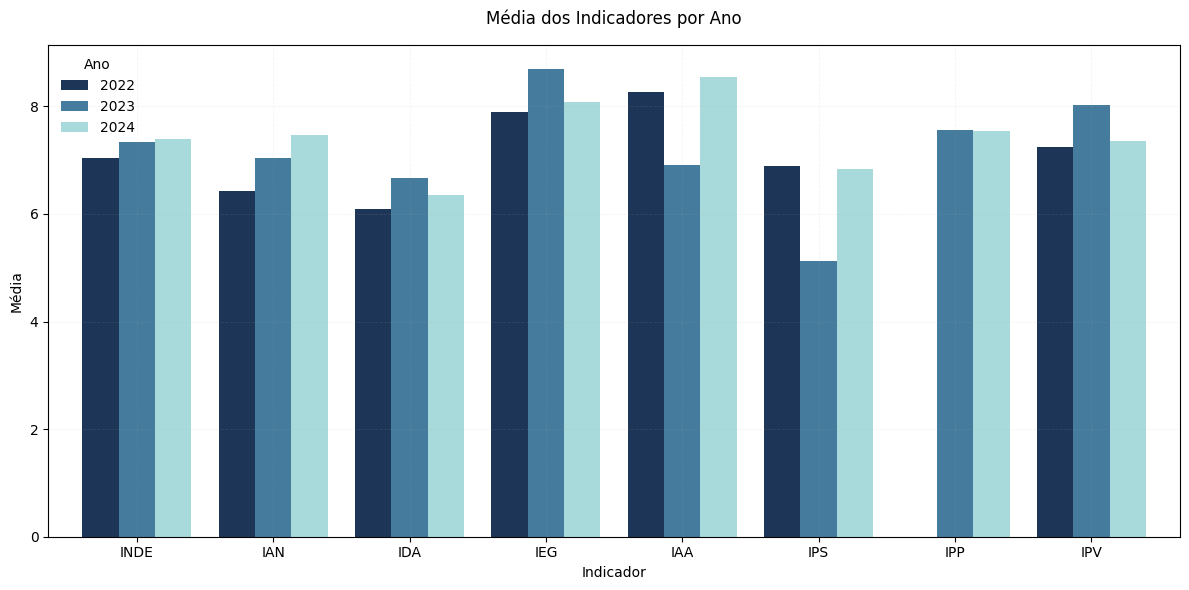

In [15]:
indicadores = [
    "INDE", "IAN", "IDA", "IEG",
    "IAA", "IPS", "IPP", "IPV"
]

indicadores_existentes = [
    col for col in indicadores
    if col in df_clean.columns
]

evolucao = (
    df_clean
    .groupby("ANO")[indicadores_existentes]
    .mean()
    .round(2)
)

cores = ["#1D3557", "#457B9D", "#A8DADC"]

ax = evolucao.T.plot(
    kind="bar",
    figsize=(12, 6),
    width=0.8,
    color=cores
)

plt.title(
    "Média dos Indicadores por Ano",
    pad=15
)

plt.xlabel("Indicador")
plt.ylabel("Média")

plt.xticks(rotation=0)

plt.grid(
    which="major",
    axis="both",
    linestyle="--",
    linewidth=0.6,
    alpha=0.15
)

plt.legend(
    title="Ano",
    frameon=False
)

plt.tight_layout()
plt.show()

### 6.3 Correlação entre os indicadores

Após analisar o comportamento temporal dos índices, a próxima etapa avalia a relação estatística entre os indicadores educacionais, acadêmicos e psicossociais. A matriz de correlação permite identificar quais variáveis apresentam maior associação com desempenho, engajamento e desenvolvimento global dos alunos.

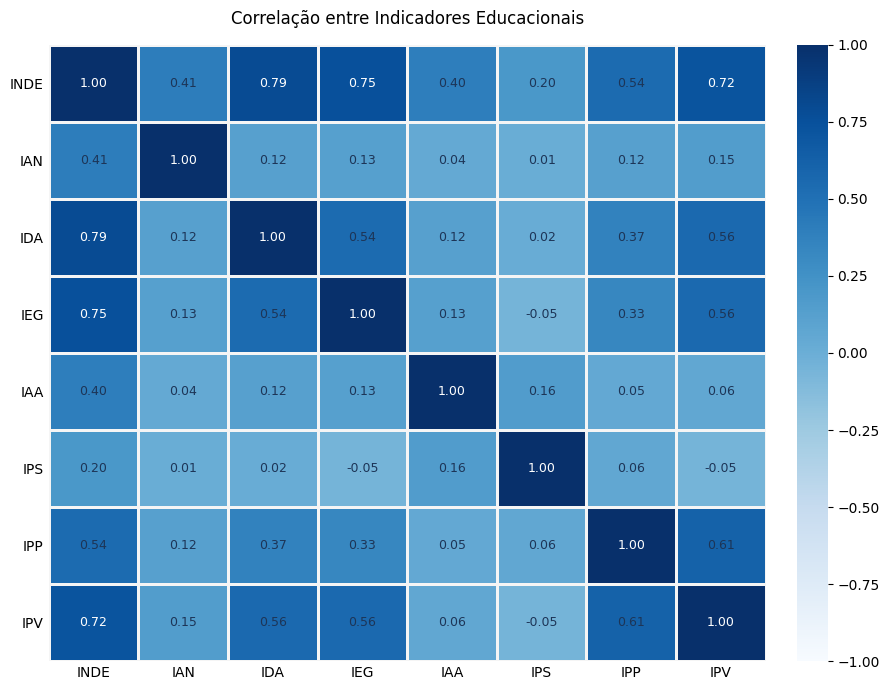

In [16]:
indicadores_corr = [
    "INDE", "IAN", "IDA", "IEG",
    "IAA", "IPS", "IPP", "IPV"
]

indicadores_corr = [
    col for col in indicadores_corr
    if col in df_clean.columns
]

correlacao = (
    df_clean[indicadores_corr]
    .corr()
    .round(2)
)

fig, ax = plt.subplots(figsize=(9, 7))

im = ax.pcolormesh(
    correlacao.values,
    cmap="Blues",
    vmin=-1,
    vmax=1,
    edgecolors="#F5F5F5",
    linewidth=2
)

ax.set_xticks(np.arange(len(correlacao.columns)) + 0.5)
ax.set_yticks(np.arange(len(correlacao.columns)) + 0.5)

ax.set_xticklabels(correlacao.columns)
ax.set_yticklabels(correlacao.columns)

ax.invert_yaxis()
ax.grid(False)

for i in range(len(correlacao)):
    for j in range(len(correlacao)):

        valor = correlacao.iloc[i, j]

        cor_texto = (
            "white"
            if abs(valor) >= 0.70
            else "#1D3557"
        )

        ax.text(
            j + 0.5,
            i + 0.5,
            f"{valor:.2f}",
            ha="center",
            va="center",
            fontsize=9,
            color=cor_texto
        )

ax.set_title(
    "Correlação entre Indicadores Educacionais",
    pad=15
)

for spine in ax.spines.values():
    spine.set_visible(False)

ax.tick_params(axis="both", length=0)

cbar = plt.colorbar(
    im,
    fraction=0.046,
    pad=0.04
)

cbar.outline.set_visible(False)

plt.tight_layout()
plt.show()

A matriz de correlação evidencia forte associação entre o índice global de desenvolvimento educacional (INDE), o desempenho acadêmico (IDA) e o engajamento dos alunos (IEG). O ponto de virada (IPV) também demonstra relação moderada com esses indicadores, sugerindo influência conjunta de fatores acadêmicos e comportamentais na evolução dos estudantes.

Por outro lado, indicadores como IAA e IPS apresentaram correlações mais baixas com desempenho acadêmico e desenvolvimento global, indicando que fatores subjetivos e psicossociais podem exigir análises complementares mais segmentadas.

## 7.Respostas às perguntas de negócio (1 a 8)

Após a análise exploratória dos indicadores, **inicia-se a etapa de resposta às perguntas estratégicas do Datathon**. O objetivo é interpretar os indicadores do PEDE sob a perspectiva de desempenho, engajamento, desenvolvimento e risco educacional.

*Obs: O enunciado das questões de 1 a 8 estarão em negrito em cada subseção.*

### 7.1 Evolução do Índice de Adequação de Nível (IAN)
**Qual é o perfil geral de defasagem dos alunos (IAN) e como ele evolui ao longo do ano?**

O IAN mede o grau de adequação do aluno em relação à fase educacional esperada para sua idade e trajetória acadêmica. A análise deste indicador permite avaliar sinais de redução ou agravamento da defasagem educacional ao longo dos ciclos do programa.

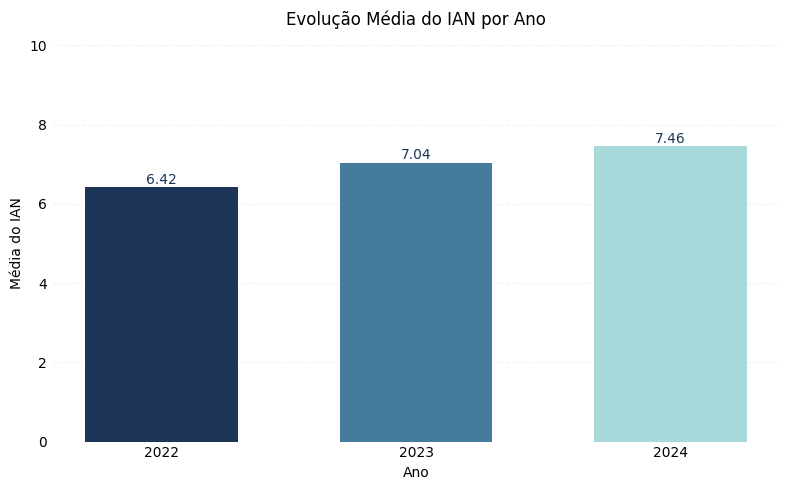

In [17]:
ian_ano = (
    df_clean
    .groupby("ANO")["IAN"]
    .mean()
    .round(2)
)

plt.figure(figsize=(8, 5))

cores = ["#1D3557", "#457B9D", "#A8DADC"]

ax = plt.gca()

bars = ax.bar(
    ian_ano.index.astype(str),
    ian_ano.values,
    color=cores,
    width=0.6,
    zorder=3
)

for bar in bars:

    altura = bar.get_height()

    ax.text(
        bar.get_x() + bar.get_width() / 2,
        altura + 0.08,
        f"{altura:.2f}",
        ha="center",
        fontsize=10,
        color="#1D3557"
    )

ax.set_title(
    "Evolução Média do IAN por Ano",
    pad=15
)

ax.set_xlabel("Ano")
ax.set_ylabel("Média do IAN")

ax.set_ylim(0, 10)

ax.grid(
    axis="y",
    linestyle="--",
    alpha=0.15,
    zorder=0
)

ax.xaxis.grid(False)

for spine in ax.spines.values():
    spine.set_visible(False)

ax.tick_params(axis="y", length=0)
ax.tick_params(axis="x", length=0)

plt.tight_layout()
plt.show()

### Perfil de defasagem dos alunos

A média do IAN indica a tendência geral de adequação de nível, mas não mostra a distribuição dos alunos entre diferentes níveis de defasagem. Para responder à pergunta de negócio, o IAN será classificado em faixas, permitindo identificar quantos alunos estão em fase, em defasagem moderada ou em defasagem severa.

In [18]:
def classificar_defasagem(ian):
    if ian >= 10:
        return "Em fase"
    elif ian >= 5:
        return "Defasagem moderada"
    else:
        return "Defasagem severa"


df_clean["FAIXA_DEFASAGEM"] = df_clean["IAN"].apply(classificar_defasagem)

ordem_defasagem = [
    "Em fase",
    "Defasagem moderada",
    "Defasagem severa"
]

perfil_defasagem = (
    df_clean
    .groupby(["ANO", "FAIXA_DEFASAGEM"])
    .size()
    .unstack(fill_value=0)
)

perfil_defasagem = perfil_defasagem[
    [col for col in ordem_defasagem if col in perfil_defasagem.columns]
]

print("--- Perfil de Defasagem por Ano ---\n")

for ano in perfil_defasagem.index:
    print(f"{ano}")

    for faixa in perfil_defasagem.columns:
        quantidade = perfil_defasagem.loc[ano, faixa]
        print(f"  {faixa:<22}: {quantidade}")

    print()

--- Perfil de Defasagem por Ano ---

2022
  Em fase               : 259
  Defasagem moderada    : 573
  Defasagem severa      : 28

2023
  Em fase               : 387
  Defasagem moderada    : 531
  Defasagem severa      : 13

2024
  Em fase               : 520
  Defasagem moderada    : 531
  Defasagem severa      : 3



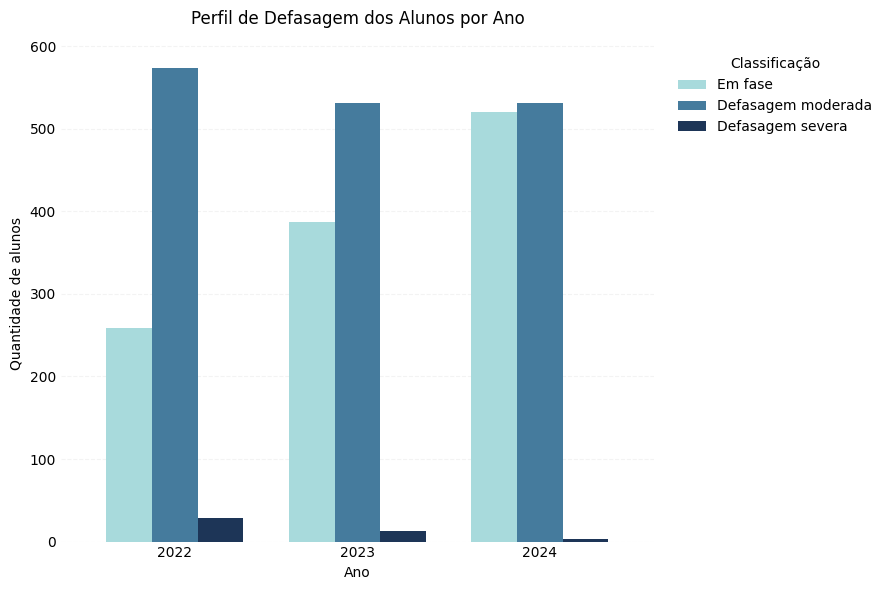

In [19]:
perfil_plot = perfil_defasagem.copy()

cores = ["#A8DADC", "#457B9D", "#1D3557"]

ax = perfil_plot.plot(
    kind="bar",
    figsize=(9, 6),
    color=cores,
    width=0.75,
    zorder=3
)

plt.title(
    "Perfil de Defasagem dos Alunos por Ano",
    pad=15
)

plt.xlabel("Ano")
plt.ylabel("Quantidade de alunos")

plt.xticks(rotation=0)

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.15,
    zorder=0
)

ax.xaxis.grid(False)

for spine in ax.spines.values():
    spine.set_visible(False)

ax.tick_params(axis="x", length=0)
ax.tick_params(axis="y", length=0)

plt.legend(
    title="Classificação",
    frameon=False,
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

### Conclusões sobre o IAN

Os resultados indicam evolução consistente do índice de adequação de nível entre 2022 e 2024. Observou-se crescimento contínuo dos alunos classificados “Em fase”, acompanhado por forte redução da defasagem severa.

Apesar da melhora geral, a maior parte dos estudantes ainda permanece em condição de defasagem moderada, indicando necessidade de acompanhamento contínuo para consolidação da evolução educacional.

### 7.2 Desempenho acadêmico dos alunos (IDA)
**O desempenho acadêmico médio (IDA) está melhorando, estagnado ou caindo ao longo das fases e anos?**

O IDA representa o desempenho acadêmico dos estudantes nas avaliações educacionais do programa. A análise deste indicador busca identificar a evolução do rendimento ao longo dos anos, além de possíveis padrões de estabilidade, avanço ou queda no desempenho escolar.

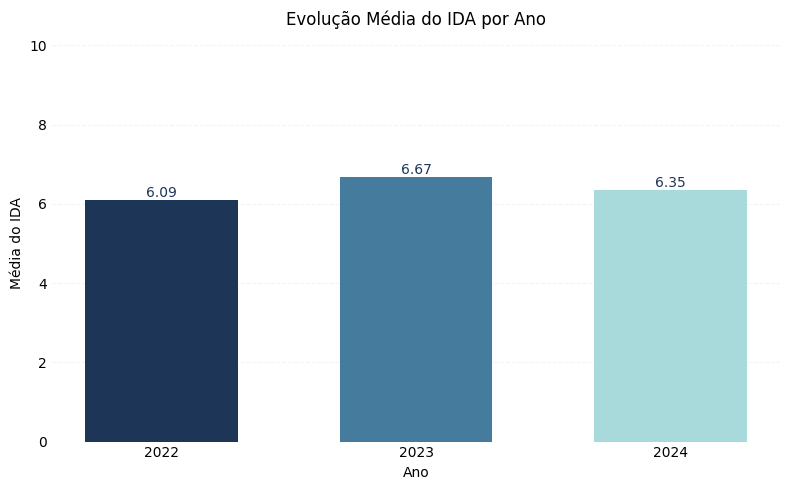

In [20]:
ida_ano = (
    df_clean
    .groupby("ANO")["IDA"]
    .mean()
    .round(2)
)

plt.figure(figsize=(8, 5))

cores = ["#1D3557", "#457B9D", "#A8DADC"]

ax = plt.gca()

bars = ax.bar(
    ida_ano.index.astype(str),
    ida_ano.values,
    color=cores,
    width=0.6,
    zorder=3
)

for bar in bars:

    altura = bar.get_height()

    ax.text(
        bar.get_x() + bar.get_width() / 2,
        altura + 0.08,
        f"{altura:.2f}",
        ha="center",
        fontsize=10,
        color="#1D3557"
    )

ax.set_title(
    "Evolução Média do IDA por Ano",
    pad=15
)

ax.set_xlabel("Ano")
ax.set_ylabel("Média do IDA")

ax.set_ylim(0, 10)

ax.grid(
    axis="y",
    linestyle="--",
    alpha=0.15,
    zorder=0
)

ax.xaxis.grid(False)

for spine in ax.spines.values():
    spine.set_visible(False)

ax.tick_params(axis="x", length=0)
ax.tick_params(axis="y", length=0)

plt.tight_layout()
plt.show()

### Distribuição do desempenho acadêmico (IDA)

Além da média anual, a distribuição do IDA permite observar a dispersão do desempenho acadêmico entre os alunos. Essa análise ajuda a identificar estabilidade, concentração das notas e possíveis variações extremas ao longo dos ciclos do programa.

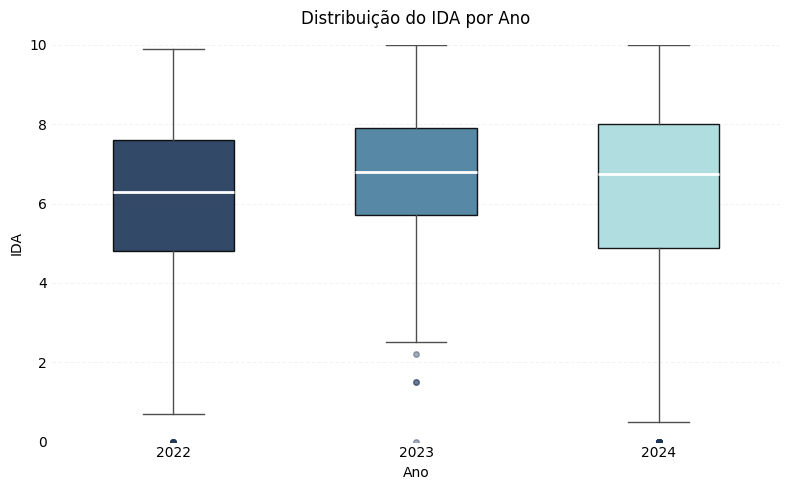

In [21]:
dados_boxplot = [
    df_clean[df_clean["ANO"] == ano]["IDA"]
    for ano in sorted(df_clean["ANO"].unique())
]

fig, ax = plt.subplots(figsize=(8, 5))

box = ax.boxplot(
    dados_boxplot,
    patch_artist=True,
    widths=0.5
)

cores = ["#1D3557", "#457B9D", "#A8DADC"]

for patch, cor in zip(box["boxes"], cores):
    patch.set_facecolor(cor)
    patch.set_alpha(0.9)

for median in box["medians"]:
    median.set_color("white")
    median.set_linewidth(2)

for whisker in box["whiskers"]:
    whisker.set_color("#4F4F4F")

for cap in box["caps"]:
    cap.set_color("#4F4F4F")

for flier in box["fliers"]:
    flier.set(
        marker="o",
        markersize=4,
        alpha=0.4,
        markerfacecolor="#1D3557",
        markeredgecolor="#1D3557"
    )

ax.set_title(
    "Distribuição do IDA por Ano",
    pad=15
)

ax.set_xlabel("Ano")
ax.set_ylabel("IDA")

ax.set_xticklabels(sorted(df_clean["ANO"].unique()))

ax.set_ylim(0, 10)

ax.grid(
    axis="y",
    linestyle="--",
    alpha=0.15
)

ax.xaxis.grid(False)

for spine in ax.spines.values():
    spine.set_visible(False)

ax.tick_params(axis="x", length=0)
ax.tick_params(axis="y", length=0)

plt.tight_layout()
plt.show()

### Desempenho acadêmico por Pedra

Além da evolução geral do IDA, a análise por Pedra permite observar como diferentes grupos do programa se comportam ao longo dos anos e identificar possíveis diferenças de desempenho entre as fases educacionais.

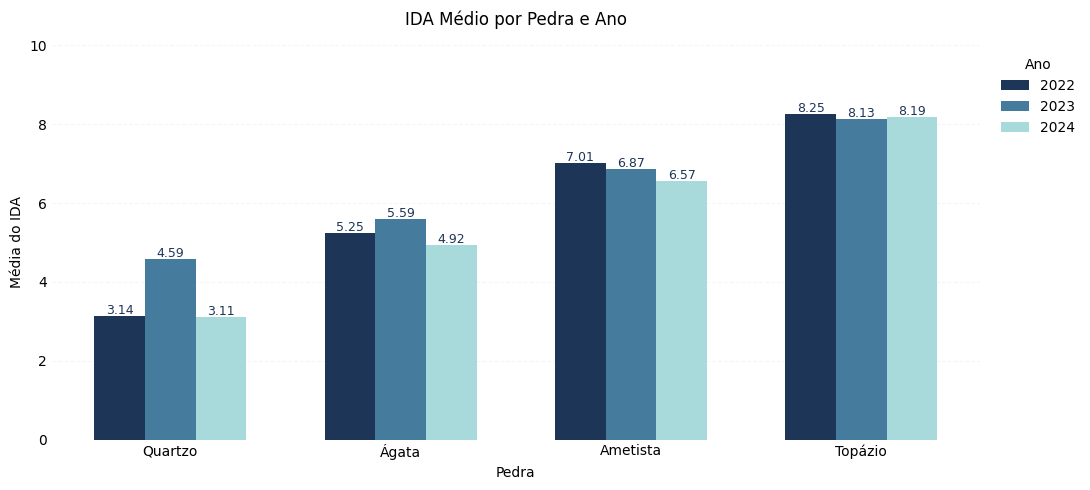

In [22]:
ida_pedra = (
    df_clean
    .groupby(["ANO", "PEDRA"])["IDA"]
    .mean()
    .reset_index()
)

ordem_pedra = [
    "Quartzo",
    "Ágata",
    "Ametista",
    "Topázio"
]

ida_pedra["PEDRA"] = pd.Categorical(
    ida_pedra["PEDRA"],
    categories=ordem_pedra,
    ordered=True
)

ida_pedra = ida_pedra.sort_values("PEDRA")

fig, ax = plt.subplots(figsize=(11, 5))

cores = {
    2022: "#1D3557",
    2023: "#457B9D",
    2024: "#A8DADC"
}

largura = 0.22
x = np.arange(len(ordem_pedra))

anos = sorted(ida_pedra["ANO"].unique())

for i, ano in enumerate(anos):

    dados_ano = ida_pedra[
        ida_pedra["ANO"] == ano
    ]

    barras = ax.bar(
        x + (i - 1) * largura,
        dados_ano["IDA"],
        width=largura,
        label=str(ano),
        color=cores[ano],
        zorder=3
    )

    for barra in barras:

        altura = barra.get_height()

        ax.text(
            barra.get_x() + barra.get_width() / 2,
            altura + 0.05,
            f"{altura:.2f}",
            ha="center",
            fontsize=9,
            color="#1D3557"
        )

ax.set_title(
    "IDA Médio por Pedra e Ano",
    pad=15
)

ax.set_xlabel("Pedra")
ax.set_ylabel("Média do IDA")

ax.set_xticks(x)
ax.set_xticklabels(ordem_pedra)

ax.set_ylim(0, 10)

ax.grid(
    axis="y",
    linestyle="--",
    alpha=0.12,
    zorder=0
)

ax.xaxis.grid(False)

for spine in ax.spines.values():
    spine.set_visible(False)

ax.tick_params(axis="x", length=0)
ax.tick_params(axis="y", length=0)

ax.legend(
    title="Ano",
    frameon=False,
    loc="upper left",
    bbox_to_anchor=(1.01, 1)
)

plt.tight_layout()
plt.show()

### Conclusões sobre o IDA

Os resultados indicam melhora do desempenho acadêmico entre 2022 e 2023, seguida por leve redução em 2024. Apesar da oscilação, a mediana do IDA permaneceu relativamente estável, sugerindo manutenção do desempenho central dos alunos.

A análise da distribuição também evidenciou aumento da variabilidade em 2024, indicando coexistência entre alunos com desempenho elevado e estudantes em situação acadêmica mais vulnerável.

A segmentação por Pedra revelou diferenças relevantes entre os grupos do programa. Quartzo e Ágata concentraram os menores desempenhos médios, enquanto Ametista e Topázio apresentaram resultados consistentemente superiores ao longo dos anos, evidenciando desigualdade de desempenho entre as fases educacionais.

### 7.3 Engajamento dos alunos (IEG)
**O grau de engajamento dos alunos (IEG) tem relação direta com seus indicadores de desempenho (IDA) e do ponto de virada (IPV)?**

O IEG representa o nível de engajamento e participação dos estudantes nas atividades do programa. A análise deste indicador busca identificar padrões de envolvimento ao longo dos anos e compreender sua relação com desempenho acadêmico (IDA) e evolução educacional dos alunos (IPV).

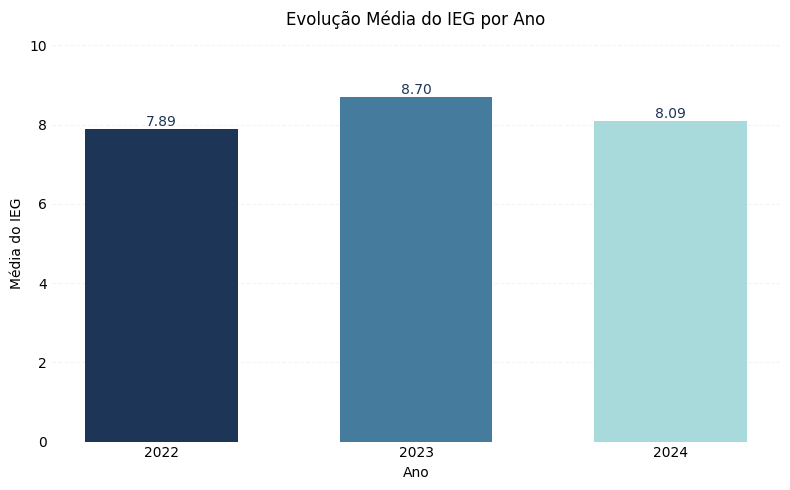

In [23]:
ieg_ano = (
    df_clean
    .groupby("ANO")["IEG"]
    .mean()
    .round(2)
)

plt.figure(figsize=(8, 5))

cores = ["#1D3557", "#457B9D", "#A8DADC"]

ax = plt.gca()

bars = ax.bar(
    ieg_ano.index.astype(str),
    ieg_ano.values,
    color=cores,
    width=0.6,
    zorder=3
)

for bar in bars:

    altura = bar.get_height()

    ax.text(
        bar.get_x() + bar.get_width() / 2,
        altura + 0.08,
        f"{altura:.2f}",
        ha="center",
        fontsize=10,
        color="#1D3557"
    )

ax.set_title(
    "Evolução Média do IEG por Ano",
    pad=15
)

ax.set_xlabel("Ano")
ax.set_ylabel("Média do IEG")

ax.set_ylim(0, 10)

ax.grid(
    axis="y",
    linestyle="--",
    alpha=0.15,
    zorder=0
)

ax.xaxis.grid(False)

for spine in ax.spines.values():
    spine.set_visible(False)

ax.tick_params(axis="x", length=0)
ax.tick_params(axis="y", length=0)

plt.tight_layout()
plt.show()

### Distribuição do engajamento dos alunos (IEG)

Além da média anual, a distribuição do IEG permite avaliar a estabilidade do engajamento entre os estudantes. Essa análise ajuda a identificar dispersão, consistência da participação e possíveis grupos com baixo envolvimento nas atividades do programa.

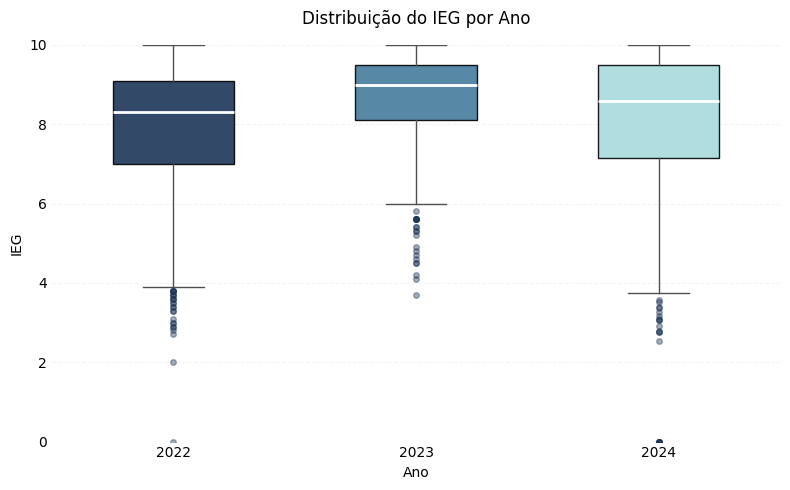

In [24]:
dados_boxplot = [
    df_clean[df_clean["ANO"] == ano]["IEG"]
    for ano in sorted(df_clean["ANO"].unique())
]

fig, ax = plt.subplots(figsize=(8, 5))

box = ax.boxplot(
    dados_boxplot,
    patch_artist=True,
    widths=0.5
)

cores = ["#1D3557", "#457B9D", "#A8DADC"]

for patch, cor in zip(box["boxes"], cores):
    patch.set_facecolor(cor)
    patch.set_alpha(0.9)

for median in box["medians"]:
    median.set_color("white")
    median.set_linewidth(2)

for whisker in box["whiskers"]:
    whisker.set_color("#4F4F4F")

for cap in box["caps"]:
    cap.set_color("#4F4F4F")

for flier in box["fliers"]:
    flier.set(
        marker="o",
        markersize=4,
        alpha=0.4,
        markerfacecolor="#1D3557",
        markeredgecolor="#1D3557"
    )

ax.set_title(
    "Distribuição do IEG por Ano",
    pad=15
)

ax.set_xlabel("Ano")
ax.set_ylabel("IEG")

ax.set_xticklabels(sorted(df_clean["ANO"].unique()))

ax.set_ylim(0, 10)

ax.grid(
    axis="y",
    linestyle="--",
    alpha=0.15
)

ax.xaxis.grid(False)

for spine in ax.spines.values():
    spine.set_visible(False)

ax.tick_params(axis="x", length=0)
ax.tick_params(axis="y", length=0)

plt.tight_layout()
plt.show()

### Relação entre engajamento, desempenho e evolução educacional

Para responder se o engajamento dos alunos tem relação com desempenho acadêmico e ponto de virada, esta análise compara o IEG com o IDA e o IPV. A matriz de correlação resume a intensidade dessas relações e ajuda a identificar se o engajamento atua como um indicador associado à evolução educacional.

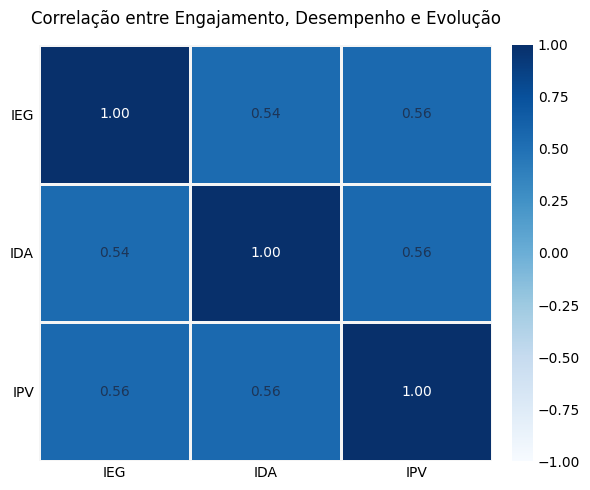

In [25]:
indicadores_relacao = [
    "IEG",
    "IDA",
    "IPV"
]

correlacao_ieg = (
    df_clean[indicadores_relacao]
    .corr()
    .round(2)
)

fig, ax = plt.subplots(figsize=(6, 5))

im = ax.pcolormesh(
    correlacao_ieg.values,
    cmap="Blues",
    vmin=-1,
    vmax=1,
    edgecolors="#F5F5F5",
    linewidth=2
)

ax.set_xticks(np.arange(len(correlacao_ieg.columns)) + 0.5)
ax.set_yticks(np.arange(len(correlacao_ieg.columns)) + 0.5)

ax.set_xticklabels(correlacao_ieg.columns)
ax.set_yticklabels(correlacao_ieg.columns)

ax.invert_yaxis()

# sem grid atravessando
ax.grid(False)

for i in range(len(correlacao_ieg)):
    for j in range(len(correlacao_ieg)):

        valor = correlacao_ieg.iloc[i, j]

        cor_texto = (
            "white"
            if abs(valor) >= 0.70
            else "#1D3557"
        )

        ax.text(
            j + 0.5,
            i + 0.5,
            f"{valor:.2f}",
            ha="center",
            va="center",
            fontsize=10,
            color=cor_texto
        )

ax.set_title(
    "Correlação entre Engajamento, Desempenho e Evolução",
    pad=15
)

for spine in ax.spines.values():
    spine.set_visible(False)

ax.tick_params(axis="both", length=0)

cbar = plt.colorbar(
    im,
    fraction=0.046,
    pad=0.04
)

cbar.outline.set_visible(False)
cbar.ax.tick_params(length=0)

plt.tight_layout()
plt.show()

### Engajamento dos alunos por Pedra

Além da evolução geral do IEG, a segmentação por Pedra permite identificar diferenças de engajamento entre os grupos do programa. Essa análise ajuda a compreender se alunos em fases mais avançadas apresentam maior participação e envolvimento nas atividades educacionais.

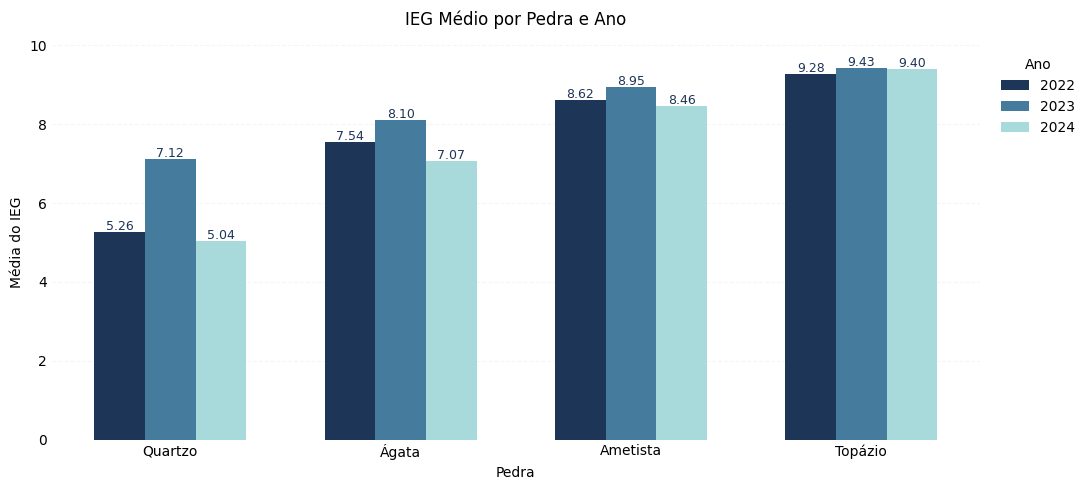

In [26]:
ieg_pedra = (
    df_clean
    .groupby(["ANO", "PEDRA"])["IEG"]
    .mean()
    .reset_index()
)

ordem_pedra = [
    "Quartzo",
    "Ágata",
    "Ametista",
    "Topázio"
]

ieg_pedra["PEDRA"] = pd.Categorical(
    ieg_pedra["PEDRA"],
    categories=ordem_pedra,
    ordered=True
)

ieg_pedra = ieg_pedra.sort_values("PEDRA")

fig, ax = plt.subplots(figsize=(11, 5))

cores = {
    2022: "#1D3557",
    2023: "#457B9D",
    2024: "#A8DADC"
}

largura = 0.22
x = np.arange(len(ordem_pedra))

anos = sorted(ieg_pedra["ANO"].unique())

for i, ano in enumerate(anos):

    dados_ano = ieg_pedra[
        ieg_pedra["ANO"] == ano
    ]

    barras = ax.bar(
        x + (i - 1) * largura,
        dados_ano["IEG"],
        width=largura,
        label=str(ano),
        color=cores[ano],
        zorder=3
    )

    for barra in barras:

        altura = barra.get_height()

        ax.text(
            barra.get_x() + barra.get_width() / 2,
            altura + 0.05,
            f"{altura:.2f}",
            ha="center",
            fontsize=9,
            color="#1D3557"
        )

ax.set_title(
    "IEG Médio por Pedra e Ano",
    pad=15
)

ax.set_xlabel("Pedra")
ax.set_ylabel("Média do IEG")

ax.set_xticks(x)
ax.set_xticklabels(ordem_pedra)

ax.set_ylim(0, 10)

ax.grid(
    axis="y",
    linestyle="--",
    alpha=0.12,
    zorder=0
)

ax.xaxis.grid(False)

for spine in ax.spines.values():
    spine.set_visible(False)

ax.tick_params(axis="x", length=0)
ax.tick_params(axis="y", length=0)

ax.legend(
    title="Ano",
    frameon=False,
    loc="upper left",
    bbox_to_anchor=(1.01, 1)
)

plt.tight_layout()
plt.show()

### Conclusões sobre o IEG

Os resultados mostram que o engajamento dos alunos permaneceu elevado ao longo da série histórica, com melhor desempenho em 2023 e leve redução em 2024.

A análise de correlação indicou associação positiva moderada entre engajamento, desempenho acadêmico e evolução educacional, sugerindo que alunos mais engajados tendem a apresentar melhores resultados no programa.

A segmentação por Pedra também revelou diferenças importantes entre os grupos. Quartzo concentrou os menores níveis médios de engajamento, enquanto Topázio apresentou os maiores índices em todos os anos analisados, indicando crescimento do envolvimento dos alunos ao longo da trajetória educacional.

### 7.4 Autoavaliação dos alunos (IAA)
**As percepções dos alunos sobre si mesmos (IAA) são coerentes com seu desempenho real (IDA) e engajamento (IEG)?**

Esta análise investiga se a autoavaliação dos estudantes é coerente com seu desempenho acadêmico e nível de engajamento nas atividades do programa.

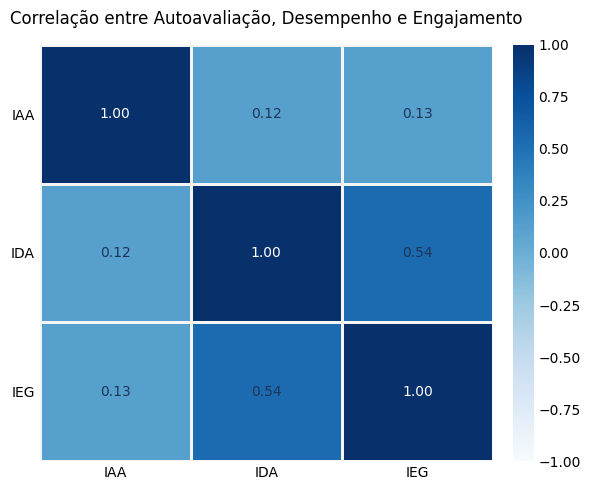

In [27]:
indicadores_iaa = [
    "IAA",
    "IDA",
    "IEG"
]

correlacao_iaa = (
    df_clean[indicadores_iaa]
    .corr()
    .round(2)
)

fig, ax = plt.subplots(figsize=(6, 5))

im = ax.pcolormesh(
    correlacao_iaa.values,
    cmap="Blues",
    vmin=-1,
    vmax=1,
    edgecolors="#F5F5F5",
    linewidth=2
)

ax.set_xticks(np.arange(len(correlacao_iaa.columns)) + 0.5)
ax.set_yticks(np.arange(len(correlacao_iaa.columns)) + 0.5)

ax.set_xticklabels(correlacao_iaa.columns)
ax.set_yticklabels(correlacao_iaa.columns)

ax.invert_yaxis()

ax.grid(False)

for i in range(len(correlacao_iaa)):
    for j in range(len(correlacao_iaa)):

        valor = correlacao_iaa.iloc[i, j]

        cor_texto = (
            "white"
            if abs(valor) >= 0.70
            else "#1D3557"
        )

        ax.text(
            j + 0.5,
            i + 0.5,
            f"{valor:.2f}",
            ha="center",
            va="center",
            fontsize=10,
            color=cor_texto
        )

ax.set_title(
    "Correlação entre Autoavaliação, Desempenho e Engajamento",
    pad=15
)

for spine in ax.spines.values():
    spine.set_visible(False)

ax.tick_params(axis="both", length=0)

cbar = plt.colorbar(
    im,
    fraction=0.046,
    pad=0.04
)

cbar.outline.set_visible(False)
cbar.ax.tick_params(length=0)

plt.tight_layout()
plt.show()

### Coerência entre autoavaliação e desempenho acadêmico

Para avaliar a coerência entre a percepção dos alunos e seus resultados reais, foi calculada a diferença média entre o IAA e o IDA em cada Pedra do programa.

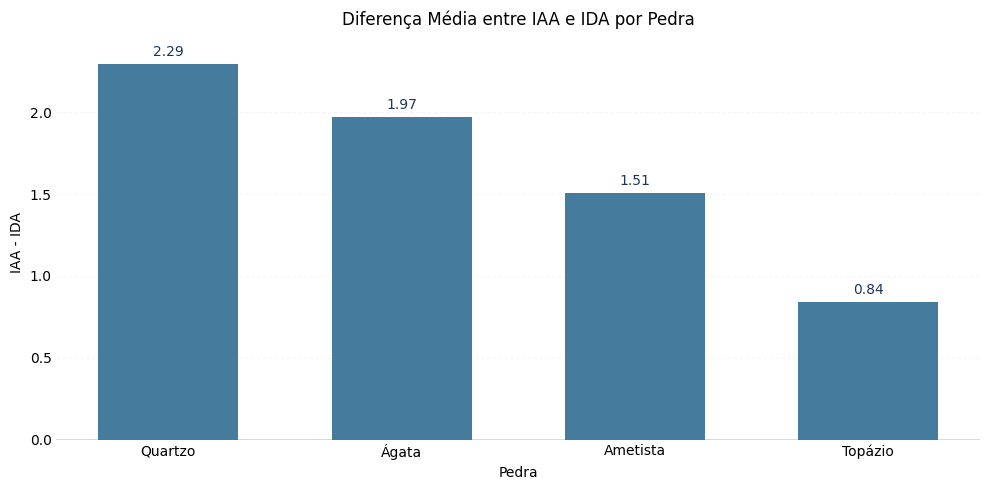

In [28]:
coerencia_iaa = (
    df_clean
    .groupby("PEDRA")[["IAA", "IDA"]]
    .mean()
    .reset_index()
)

coerencia_iaa["DIFERENCA"] = (
    coerencia_iaa["IAA"] -
    coerencia_iaa["IDA"]
)

ordem_pedra = [
    "Quartzo",
    "Ágata",
    "Ametista",
    "Topázio"
]

coerencia_iaa["PEDRA"] = pd.Categorical(
    coerencia_iaa["PEDRA"],
    categories=ordem_pedra,
    ordered=True
)

coerencia_iaa = coerencia_iaa.sort_values("PEDRA")

fig, ax = plt.subplots(figsize=(10, 5))

barras = ax.bar(
    coerencia_iaa["PEDRA"],
    coerencia_iaa["DIFERENCA"],
    color="#457B9D",
    width=0.6,
    zorder=3
)

for barra in barras:

    altura = barra.get_height()

    ax.text(
        barra.get_x() + barra.get_width() / 2,
        altura + 0.05,
        f"{altura:.2f}",
        ha="center",
        fontsize=10,
        color="#1D3557"
    )

ax.axhline(
    0,
    color="#444444",
    linewidth=1
)

ax.set_title(
    "Diferença Média entre IAA e IDA por Pedra",
    pad=15
)

ax.set_xlabel("Pedra")
ax.set_ylabel("IAA - IDA")

ax.grid(
    axis="y",
    linestyle="--",
    alpha=0.12,
    zorder=0
)

ax.xaxis.grid(False)

for spine in ax.spines.values():
    spine.set_visible(False)

ax.tick_params(axis="x", length=0)
ax.tick_params(axis="y", length=0)

plt.tight_layout()
plt.show()

### Conclusões sobre o IAA

Os resultados indicam baixa correlação entre autoavaliação, desempenho acadêmico e engajamento, sugerindo que a percepção dos alunos sobre si mesmos nem sempre reflete seus resultados reais no programa.

A análise da diferença entre IAA e IDA mostrou tendência de superestimação do desempenho em todas as Pedras, especialmente entre alunos de Quartzo e Ágata. Já estudantes de Topázio apresentaram percepções mais próximas da realidade acadêmica, indicando maior coerência entre autoavaliação e desempenho efetivo.

### 7.5 Aspectos psicossociais (IPS)
**Há padrões psicossociais (IPS) que antecedem quedas de desempenho acadêmico ou de engajamento?**

O IPS representa fatores psicossociais relacionados ao desenvolvimento dos alunos dentro do programa. Nesta etapa, buscamos investigar se aspectos emocionais, comportamentais e sociais apresentam relação com desempenho acadêmico e engajamento nas atividades educacionais.

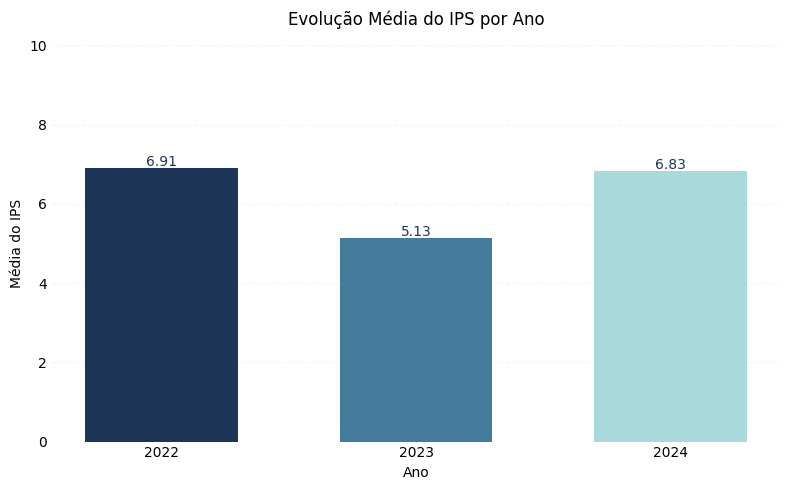

In [29]:
ips_media = (
    df_clean
    .groupby("ANO")["IPS"]
    .mean()
    .reset_index()
)

fig, ax = plt.subplots(figsize=(8, 5))

cores = ["#1D3557", "#457B9D", "#A8DADC"]

barras = ax.bar(
    ips_media["ANO"].astype(str),
    ips_media["IPS"],
    color=cores,
    width=0.6,
    zorder=3
)

for barra in barras:

    altura = barra.get_height()

    ax.text(
        barra.get_x() + barra.get_width() / 2,
        altura + 0.05,
        f"{altura:.2f}",
        ha="center",
        fontsize=10,
        color="#1D3557"
    )

ax.set_title(
    "Evolução Média do IPS por Ano",
    pad=15
)

ax.set_xlabel("Ano")
ax.set_ylabel("Média do IPS")

ax.set_ylim(0, 10)

ax.grid(
    axis="y",
    linestyle="--",
    alpha=0.12,
    zorder=0
)

ax.xaxis.grid(False)

for spine in ax.spines.values():
    spine.set_visible(False)

ax.tick_params(axis="x", length=0)
ax.tick_params(axis="y", length=0)

plt.tight_layout()
plt.show()

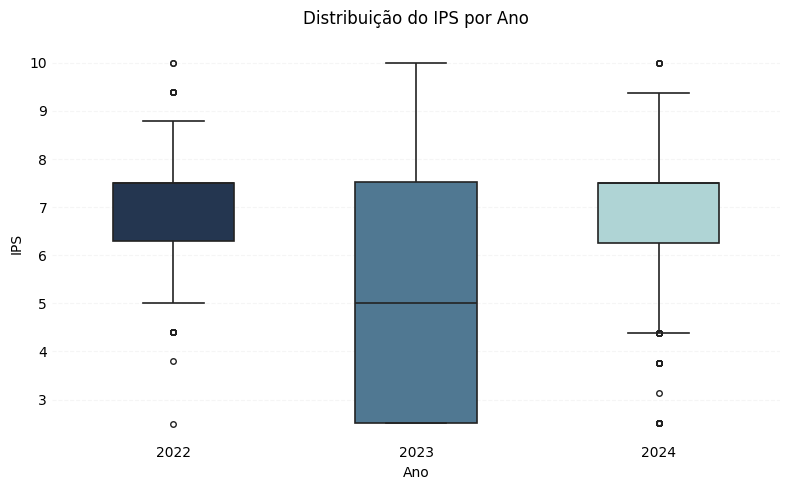

In [30]:
fig, ax = plt.subplots(figsize=(8, 5))

sns.boxplot(
    data=df_clean,
    x="ANO",
    y="IPS",
    palette=["#1D3557", "#457B9D", "#A8DADC"],
    width=0.5,
    linewidth=1.2,
    fliersize=4,
    ax=ax
)

ax.set_title(
    "Distribuição do IPS por Ano",
    pad=15
)

ax.set_xlabel("Ano")
ax.set_ylabel("IPS")

ax.grid(
    axis="y",
    linestyle="--",
    alpha=0.12,
    zorder=0
)

ax.xaxis.grid(False)

for spine in ax.spines.values():
    spine.set_visible(False)

ax.tick_params(axis="x", length=0)
ax.tick_params(axis="y", length=0)

plt.tight_layout()
plt.show()

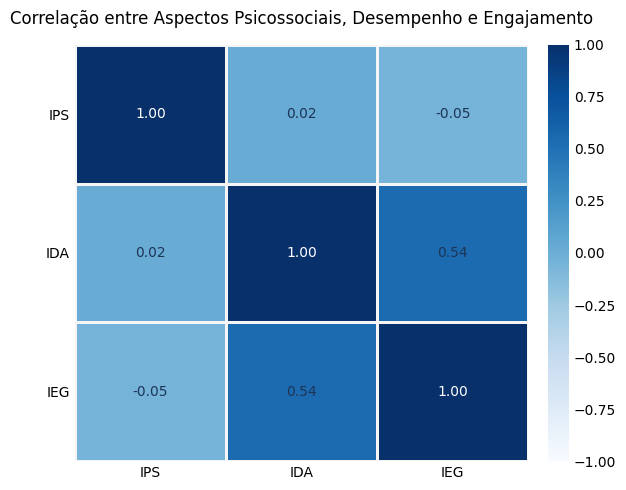

In [31]:
indicadores_ips = [
    "IPS",
    "IDA",
    "IEG"
]

correlacao_ips = (
    df_clean[indicadores_ips]
    .corr()
    .round(2)
)

fig, ax = plt.subplots(figsize=(6, 5))

im = ax.pcolormesh(
    correlacao_ips.values,
    cmap="Blues",
    vmin=-1,
    vmax=1,
    edgecolors="#F5F5F5",
    linewidth=2
)

ax.set_xticks(np.arange(len(correlacao_ips.columns)) + 0.5)
ax.set_yticks(np.arange(len(correlacao_ips.columns)) + 0.5)

ax.set_xticklabels(correlacao_ips.columns)
ax.set_yticklabels(correlacao_ips.columns)

ax.invert_yaxis()
ax.grid(False)

for i in range(len(correlacao_ips)):
    for j in range(len(correlacao_ips)):

        valor = correlacao_ips.iloc[i, j]

        cor_texto = (
            "white"
            if abs(valor) >= 0.70
            else "#1D3557"
        )

        ax.text(
            j + 0.5,
            i + 0.5,
            f"{valor:.2f}",
            ha="center",
            va="center",
            fontsize=10,
            color=cor_texto
        )

ax.set_title(
    "Correlação entre Aspectos Psicossociais, Desempenho e Engajamento",
    pad=15
)

for spine in ax.spines.values():
    spine.set_visible(False)

ax.tick_params(axis="both", length=0)

cbar = plt.colorbar(
    im,
    fraction=0.046,
    pad=0.04
)

cbar.outline.set_visible(False)
cbar.ax.tick_params(length=0)

plt.tight_layout()
plt.show()

### Conclusões sobre o IPS

Os resultados mostram queda relevante do IPS em 2023, seguida de recuperação em 2024. A distribuição também evidenciou maior variabilidade dos aspectos psicossociais em 2023, indicando aumento da heterogeneidade entre os alunos nesse período.

Apesar dessas oscilações, a análise de correlação revelou associação praticamente nula entre IPS, desempenho acadêmico e engajamento. Isso sugere que fatores psicossociais, isoladamente, não explicam diretamente os resultados acadêmicos observados no programa.

### 7.6 Aspectos psicopedagógicos (IPP)
**As avaliações psicopedagógicas (IPP) confirmam ou contradizem a defasagem identificada pelo IAN?**

O IPP representa a avaliação psicopedagógica dos estudantes, considerando aspectos cognitivos, comportamentais e socioemocionais relacionados ao desenvolvimento educacional.

Embora o indicador faça parte da metodologia oficial do PEDE em todos os ciclos, a base operacional disponibilizada para 2022 não contém os valores individuais de IPP. Dessa forma, a análise desta seção será realizada apenas para os anos de 2023 e 2024.

Nesta etapa, investigamos se as avaliações psicopedagógicas (IPP) confirmam ou contradizem os níveis de defasagem identificados pelo IAN.

In [32]:
df_ipp = (
    df_clean
    .loc[df_clean["ANO"].isin([2023, 2024])]
    .copy()
)

def classificar_defasagem_ian(ian):
    if ian == 10:
        return "Em fase"
    elif ian == 5:
        return "Defasagem moderada"
    elif ian == 2.5:
        return "Defasagem severa"
    else:
        return "Não classificado"


df_ipp["FAIXA_DEFASAGEM"] = (
    df_ipp["IAN"]
    .apply(classificar_defasagem_ian)
)

print("--- Base utilizada na análise do IPP ---\n")

print("Registros por ano:")
print(
    df_ipp["ANO"]
    .value_counts()
    .sort_index()
)

print("\nValores ausentes nos indicadores analisados:")
print(
    df_ipp[["IPP", "IAN"]]
    .isna()
    .sum()
)

print("\nDistribuição das faixas de defasagem:")
print(
    df_ipp["FAIXA_DEFASAGEM"]
    .value_counts()
)

--- Base utilizada na análise do IPP ---

Registros por ano:
ANO
2023     931
2024    1054
Name: count, dtype: int64

Valores ausentes nos indicadores analisados:
IPP    0
IAN    0
dtype: int64

Distribuição das faixas de defasagem:
FAIXA_DEFASAGEM
Defasagem moderada    1062
Em fase                907
Defasagem severa        16
Name: count, dtype: int64


### IPP médio por faixa de defasagem

O gráfico a seguir compara a média do IPP entre alunos em fase, com defasagem moderada e com defasagem severa. A ideia é verificar se a avaliação psicopedagógica acompanha a defasagem identificada pelo IAN.

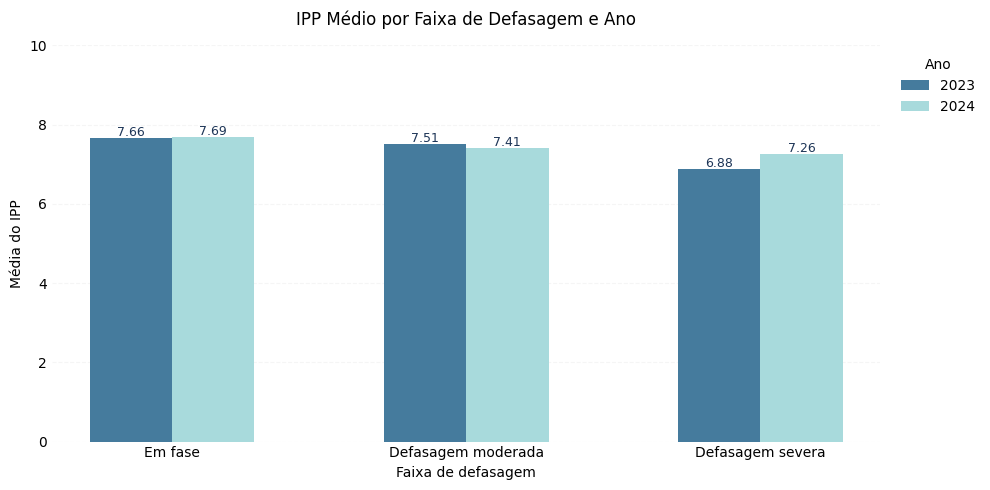

In [33]:
ipp_defasagem = (
    df_ipp
    .groupby(["ANO", "FAIXA_DEFASAGEM"])["IPP"]
    .mean()
    .reset_index()
)

ordem_defasagem = [
    "Em fase",
    "Defasagem moderada",
    "Defasagem severa"
]

ipp_defasagem["FAIXA_DEFASAGEM"] = pd.Categorical(
    ipp_defasagem["FAIXA_DEFASAGEM"],
    categories=ordem_defasagem,
    ordered=True
)

ipp_defasagem = ipp_defasagem.sort_values(
    ["FAIXA_DEFASAGEM", "ANO"]
)

fig, ax = plt.subplots(figsize=(10, 5))

cores = {
    2023: "#457B9D",
    2024: "#A8DADC"
}

largura = 0.28
x = np.arange(len(ordem_defasagem))

anos = sorted(ipp_defasagem["ANO"].unique())

for i, ano in enumerate(anos):

    dados_ano = ipp_defasagem[
        ipp_defasagem["ANO"] == ano
    ]

    valores = []

    for faixa in ordem_defasagem:

        valor = dados_ano.loc[
            dados_ano["FAIXA_DEFASAGEM"] == faixa,
            "IPP"
        ]

        valores.append(
            valor.iloc[0]
            if len(valor) > 0
            else np.nan
        )

    barras = ax.bar(
        x + (i - 0.5) * largura,
        valores,
        width=largura,
        label=str(ano),
        color=cores[ano],
        zorder=3
    )

    for barra in barras:

        altura = barra.get_height()

        if not np.isnan(altura):
            ax.text(
                barra.get_x() + barra.get_width() / 2,
                altura + 0.05,
                f"{altura:.2f}",
                ha="center",
                fontsize=9,
                color="#1D3557"
            )

ax.set_title(
    "IPP Médio por Faixa de Defasagem e Ano",
    pad=15
)

ax.set_xlabel("Faixa de defasagem")
ax.set_ylabel("Média do IPP")

ax.set_xticks(x)
ax.set_xticklabels(ordem_defasagem)

ax.set_ylim(0, 10)

ax.grid(
    axis="y",
    linestyle="--",
    alpha=0.12,
    zorder=0
)

ax.xaxis.grid(False)

for spine in ax.spines.values():
    spine.set_visible(False)

ax.tick_params(axis="x", length=0)
ax.tick_params(axis="y", length=0)

ax.legend(
    title="Ano",
    frameon=False,
    loc="upper left",
    bbox_to_anchor=(1.01, 1)
)

plt.tight_layout()
plt.show()

### 7.7 Ponto de Virada (IPV)

**Quais comportamentos — acadêmicos, emocionais ou de engajamento — mais influenciam o IPV ao longo do tempo?**

O IPV mede o grau de desenvolvimento do aluno em direção ao ponto de virada, momento em que o estudante demonstra autonomia, engajamento consistente e evolução sustentada. Nesta análise, investigamos quais indicadores têm maior associação com o IPV, permitindo identificar os fatores que mais contribuem para essa evolução.

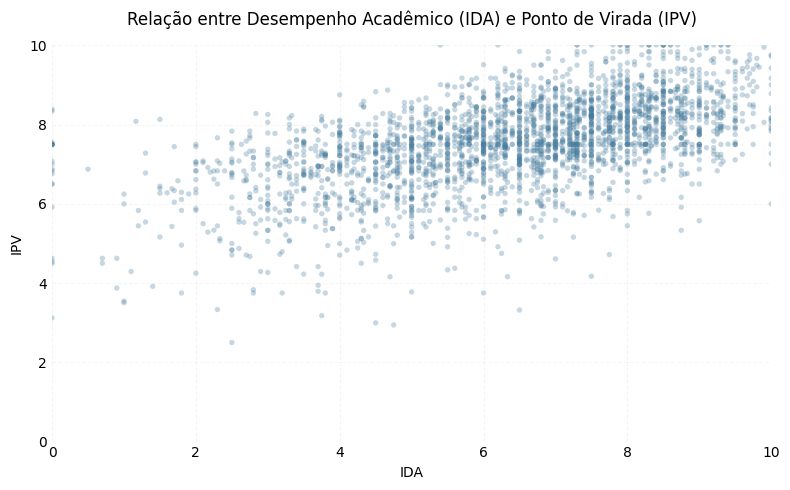

In [34]:
fig, ax = plt.subplots(figsize=(8, 5))

ax.scatter(
    df_clean["IDA"],
    df_clean["IPV"],
    alpha=0.3,
    s=15,
    color="#457B9D",
    edgecolors="none"
)

ax.set_title(
    "Relação entre Desempenho Acadêmico (IDA) e Ponto de Virada (IPV)",
    pad=15
)
ax.set_xlabel("IDA")
ax.set_ylabel("IPV")
ax.set_xlim(0, 10)
ax.set_ylim(0, 10)
ax.grid(linestyle="--", alpha=0.12)

for spine in ax.spines.values():
    spine.set_visible(False)

ax.tick_params(length=0)
plt.tight_layout()
plt.show()

### Correlação entre IPV e os demais indicadores

Para identificar quais dimensões — acadêmica, emocional ou de engajamento — têm maior influência sobre o ponto de virada, a matriz de correlação a seguir compara o IPV com os principais indicadores do PEDE.

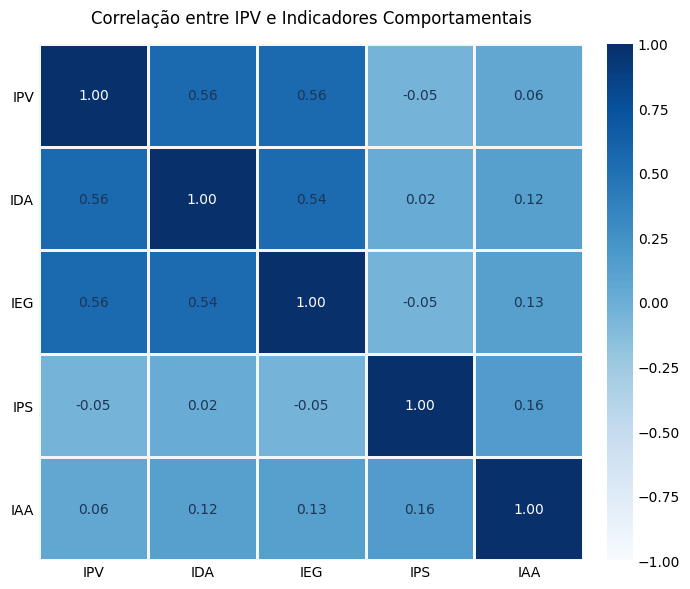

In [35]:
indicadores_ipv = ["IPV", "IDA", "IEG", "IPS", "IAA"]
indicadores_ipv = [c for c in indicadores_ipv if c in df_clean.columns]

corr_ipv = df_clean[indicadores_ipv].corr().round(2)

fig, ax = plt.subplots(figsize=(7, 6))

im = ax.pcolormesh(
    corr_ipv.values,
    cmap="Blues",
    vmin=-1,
    vmax=1,
    edgecolors="#F5F5F5",
    linewidth=2
)

ax.set_xticks(np.arange(len(corr_ipv.columns)) + 0.5)
ax.set_yticks(np.arange(len(corr_ipv.columns)) + 0.5)
ax.set_xticklabels(corr_ipv.columns)
ax.set_yticklabels(corr_ipv.columns)
ax.invert_yaxis()
ax.grid(False)

for i in range(len(corr_ipv)):
    for j in range(len(corr_ipv)):
        valor = corr_ipv.iloc[i, j]
        cor_texto = "white" if abs(valor) >= 0.70 else "#1D3557"
        ax.text(
            j + 0.5, i + 0.5,
            f"{valor:.2f}",
            ha="center",
            va="center",
            fontsize=10,
            color=cor_texto
        )

ax.set_title(
    "Correlação entre IPV e Indicadores Comportamentais",
    pad=15
)

for spine in ax.spines.values():
    spine.set_visible(False)

ax.tick_params(axis="both", length=0)

cbar = plt.colorbar(im, fraction=0.046, pad=0.04)
cbar.outline.set_visible(False)
cbar.ax.tick_params(length=0)

plt.tight_layout()
plt.show()

### Conclusões sobre o IPV

A matriz de correlação revela que IDA e IEG são os únicos indicadores com associação relevante ao IPV, ambos com correlação de 0.56. Indicadores psicossociais (IPS = -0.05) e de autoavaliação (IAA = 0.06) não apresentam relação mensurável com o ponto de virada.

A dispersão entre IDA e IPV confirma a tendência positiva, mas com variabilidade considerável — especialmente entre alunos com IDA entre 6 e 9, onde o IPV oscila amplamente. Isso indica que desempenho acadêmico elevado favorece o ponto de virada, mas não o determina sozinho.

O achado central desta análise é que o ponto de virada é essencialmente explicado pela combinação de desempenho acadêmico e engajamento. Fatores emocionais e de autopercepção, isoladamente, não antecipam essa evolução — o que sugere que intervenções focadas em IDA e IEG têm maior potencial de impacto sobre o IPV dos alunos.

### 7.8 Multidimensionalidade dos indicadores (INDE)

**Quais combinações de indicadores (IDA + IEG + IPS + IPP) elevam mais a nota global do aluno (INDE)?**

O INDE representa o índice consolidado de desenvolvimento educacional, calculado pela ponderação dos indicadores do PEDE. Nesta análise, investigamos quais indicadores têm maior associação com o INDE, permitindo identificar as combinações que mais contribuem para a evolução global do aluno.

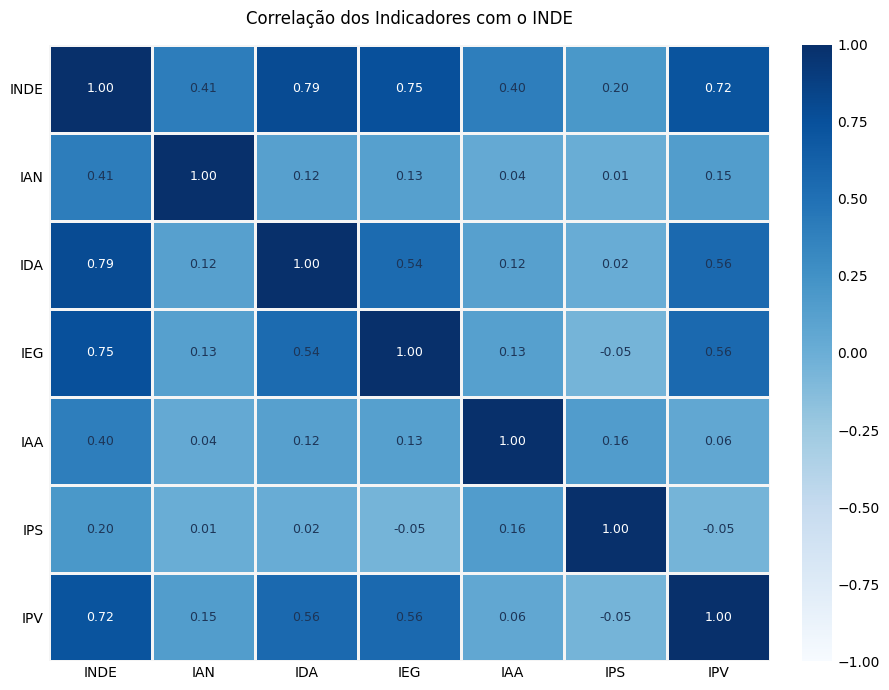

In [36]:
indicadores_inde = ["INDE", "IAN", "IDA", "IEG", "IAA", "IPS", "IPV"]
indicadores_inde = [c for c in indicadores_inde if c in df_clean.columns]

corr_inde = df_clean[indicadores_inde].corr().round(2)

fig, ax = plt.subplots(figsize=(9, 7))

im = ax.pcolormesh(
    corr_inde.values,
    cmap="Blues",
    vmin=-1,
    vmax=1,
    edgecolors="#F5F5F5",
    linewidth=2
)

ax.set_xticks(np.arange(len(corr_inde.columns)) + 0.5)
ax.set_yticks(np.arange(len(corr_inde.columns)) + 0.5)
ax.set_xticklabels(corr_inde.columns)
ax.set_yticklabels(corr_inde.columns)
ax.invert_yaxis()
ax.grid(False)

for i in range(len(corr_inde)):
    for j in range(len(corr_inde)):
        valor = corr_inde.iloc[i, j]
        cor_texto = "white" if abs(valor) >= 0.70 else "#1D3557"
        ax.text(
            j + 0.5, i + 0.5,
            f"{valor:.2f}",
            ha="center",
            va="center",
            fontsize=9,
            color=cor_texto
        )

ax.set_title("Correlação dos Indicadores com o INDE", pad=15)

for spine in ax.spines.values():
    spine.set_visible(False)

ax.tick_params(axis="both", length=0)

cbar = plt.colorbar(im, fraction=0.046, pad=0.04)
cbar.outline.set_visible(False)
cbar.ax.tick_params(length=0)

plt.tight_layout()
plt.show()

### Contribuição individual dos indicadores para o INDE

Para identificar quais indicadores mais elevam a nota global do aluno, a correlação de cada dimensão do PEDE com o INDE é apresentada em ordem decrescente de influência.

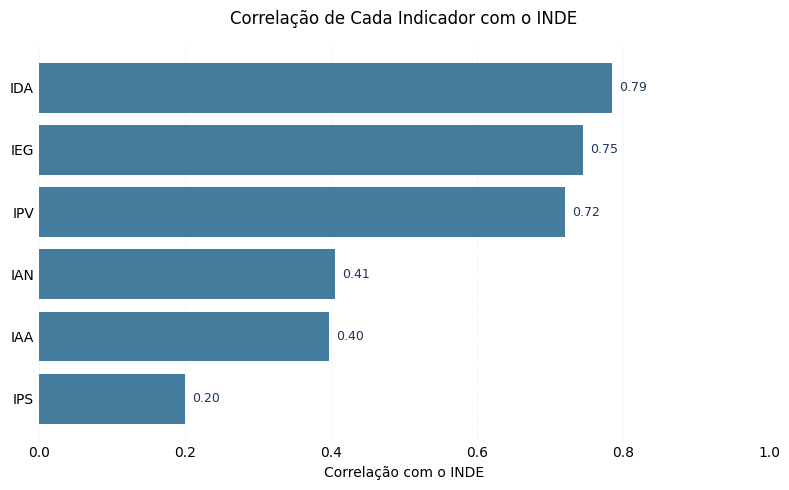

In [37]:
indicadores_contrib = ["IAN", "IDA", "IEG", "IAA", "IPS", "IPV"]
indicadores_contrib = [c for c in indicadores_contrib if c in df_clean.columns]

corr_com_inde = (
    df_clean[indicadores_contrib + ["INDE"]]
    .corr()["INDE"]
    .drop("INDE")
    .sort_values(ascending=True)
)

fig, ax = plt.subplots(figsize=(8, 5))

barras = ax.barh(
    corr_com_inde.index,
    corr_com_inde.values,
    color="#457B9D",
    zorder=3
)

for barra in barras:
    larg = barra.get_width()
    ax.text(
        larg + 0.01,
        barra.get_y() + barra.get_height() / 2,
        f"{larg:.2f}",
        va="center",
        fontsize=9,
        color="#1D3557"
    )

ax.set_title(
    "Correlação de Cada Indicador com o INDE",
    pad=15
)
ax.set_xlabel("Correlação com o INDE")
ax.set_xlim(0, 1)
ax.grid(axis="x", linestyle="--", alpha=0.12, zorder=0)
ax.yaxis.grid(False)

for spine in ax.spines.values():
    spine.set_visible(False)

ax.tick_params(length=0)
plt.tight_layout()
plt.show()

### Conclusões sobre a multidimensionalidade dos indicadores

Os resultados confirmam que o INDE é predominantemente determinado por três indicadores: IDA (0.79), IEG (0.75) e IPV (0.72). A combinação dessas três dimensões — desempenho acadêmico, engajamento e ponto de virada — explica a maior parte da variação no índice global do aluno.

IAN e IAA apresentam correlação moderada com o INDE (0.41 e 0.40), contribuindo de forma secundária. O IPS, com correlação de apenas 0.20, tem influência marginal sobre a nota global, reforçando o achado da seção anterior de que fatores psicossociais atuam de forma independente dos demais indicadores do programa.

Para elevar o INDE de um aluno, portanto, as intervenções mais efetivas são aquelas que atuam simultaneamente sobre desempenho acadêmico, engajamento nas atividades e desenvolvimento em direção ao ponto de virada.

## 8.Modelo Preditivo de Risco Educacional

Esta seção responde à pergunta 9 do Datathon:

**"Quais padrões nos indicadores permitem identificar alunos em risco antes de queda no desempenho ou aumento da defasagem?"**

A construção do modelo segue as etapas de análise exploratória do risco, feature engineering, modelagem preditiva e avaliação dos resultados.

### 8.1 Análise exploratória do risco educacional

Para construir o modelo preditivo, é necessário primeiro definir o que caracteriza um aluno em risco. A partir dos indicadores do PEDE, um aluno é classificado como em risco quando apresenta defasagem severa (IAN = 2.5) ou desempenho acadêmico abaixo do limiar crítico (IDA < 5.0). Essa definição operacional permite transformar o problema em uma tarefa de classificação binária supervisionada.

Nesta etapa, a distribuição do risco é analisada por ano e por classificação de pedra, permitindo compreender o perfil dos alunos em situação de vulnerabilidade educacional antes da modelagem.

--- Distribuição do Risco Educacional ---

Total de registros : 2845
Em risco (1)       : 654  (23.0%)
Sem risco (0)      : 2191 (77.0%)

--- Risco por Ano ---

      Em risco  Total  % Risco
ANO                           
2022       247    860    28.70
2023       141    931    15.10
2024       266   1054    25.20


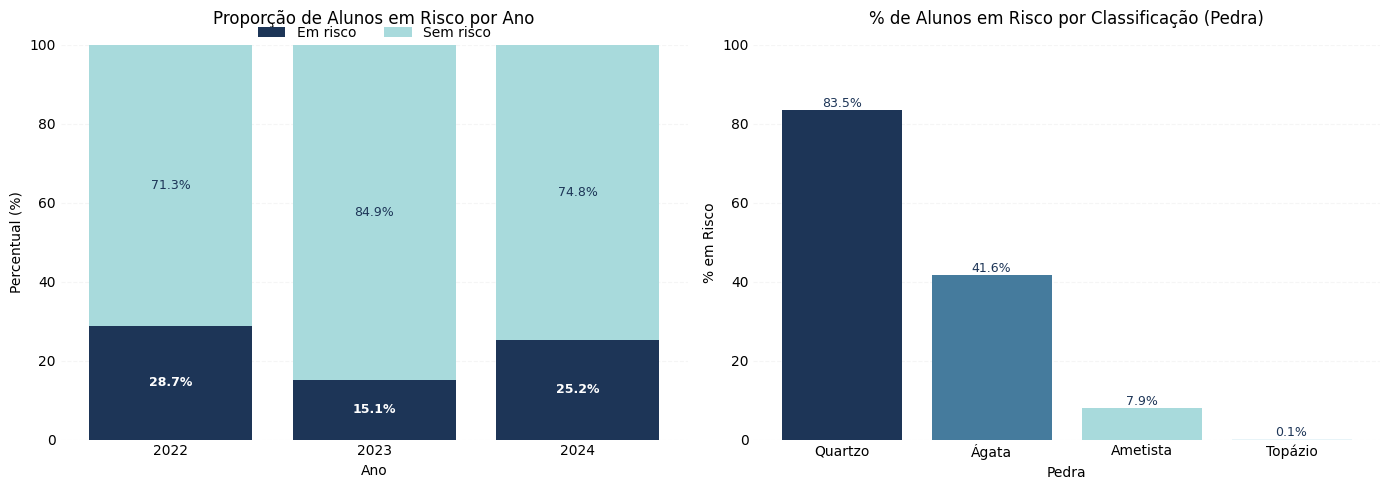

In [38]:
# Definição do target: aluno em risco educacional
df_clean["RISCO"] = (
    (df_clean["IAN"] == 2.5) | (df_clean["IDA"] < 5.0)
).astype(int)

total = len(df_clean)
em_risco = df_clean["RISCO"].sum()
sem_risco = total - em_risco

print("--- Distribuição do Risco Educacional ---\n")
print(f"Total de registros : {total}")
print(f"Em risco (1)       : {em_risco}  ({em_risco/total*100:.1f}%)")
print(f"Sem risco (0)      : {sem_risco} ({sem_risco/total*100:.1f}%)")

risco_ano = (
    df_clean.groupby("ANO")["RISCO"]
    .agg(["sum", "count"])
    .rename(columns={"sum": "Em risco", "count": "Total"})
)

risco_ano["% Risco"] = (
    risco_ano["Em risco"] / risco_ano["Total"] * 100
).round(1)

print("\n--- Risco por Ano ---\n")
print(risco_ano.to_string())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

anos = risco_ano.index.astype(str)
perc_risco = risco_ano["% Risco"].values
perc_sem = 100 - perc_risco

b1 = axes[0].bar(
    anos,
    perc_risco,
    color="#1D3557",
    zorder=3,
    label="Em risco"
)

b2 = axes[0].bar(
    anos,
    perc_sem,
    bottom=perc_risco,
    color="#A8DADC",
    zorder=3,
    label="Sem risco"
)

for i, pr in enumerate(perc_risco):

    ps = 100 - pr

    axes[0].text(
        i,
        pr / 2,
        f"{pr:.1f}%",
        ha="center",
        va="center",
        fontsize=9,
        color="white",
        fontweight="bold"
    )

    axes[0].text(
        i,
        pr + ps / 2,
        f"{ps:.1f}%",
        ha="center",
        va="center",
        fontsize=9,
        color="#1D3557"
    )

axes[0].set_title(
    "Proporção de Alunos em Risco por Ano",
    pad=15
)

axes[0].set_xlabel("Ano")
axes[0].set_ylabel("Percentual (%)")
axes[0].set_ylim(0, 100)

axes[0].grid(
    axis="y",
    linestyle="--",
    alpha=0.12,
    zorder=0
)

axes[0].xaxis.grid(False)

for spine in axes[0].spines.values():
    spine.set_visible(False)

axes[0].tick_params(length=0)

axes[0].legend(
    frameon=False,
    loc="upper center",
    bbox_to_anchor=(0.5, 1.08),
    ncol=2
)

pedras_ordem = ["Quartzo", "Ágata", "Ametista", "Topázio"]

risco_pedra = (
    df_clean[df_clean["PEDRA"].isin(pedras_ordem)]
    .groupby("PEDRA")["RISCO"]
    .mean()
    .reindex(pedras_ordem) * 100
)

cores_pedra = [
    "#1D3557",
    "#457B9D",
    "#A8DADC",
    "#E8F4F8"
]

barras = axes[1].bar(
    risco_pedra.index,
    risco_pedra.values,
    color=cores_pedra,
    zorder=3
)

for barra in barras:

    h = barra.get_height()

    axes[1].text(
        barra.get_x() + barra.get_width() / 2,
        h + 0.8,
        f"{h:.1f}%",
        ha="center",
        fontsize=9,
        color="#1D3557"
    )

axes[1].set_title(
    "% de Alunos em Risco por Classificação (Pedra)",
    pad=15
)

axes[1].set_xlabel("Pedra")
axes[1].set_ylabel("% em Risco")
axes[1].set_ylim(0, 100)

axes[1].grid(
    axis="y",
    linestyle="--",
    alpha=0.12,
    zorder=0
)

axes[1].xaxis.grid(False)

for spine in axes[1].spines.values():
    spine.set_visible(False)

axes[1].tick_params(length=0)

plt.tight_layout()
plt.show()

### 8.2 Feature engineering

Com o target definido, esta etapa prepara as variáveis preditoras para o modelo. São criadas features derivadas que capturam relações entre os indicadores do PEDE — como distância entre autoavaliação e desempenho real, e combinações entre engajamento e ponto de virada — além da codificação das variáveis categóricas necessárias para o algoritmo de classificação.

In [39]:
from sklearn.preprocessing import LabelEncoder

df_model = df_clean.copy()

# Features derivadas
df_model["DELTA_IAA_IDA"] = df_model["IAA"] - df_model["IDA"]
df_model["IEG_x_IPV"]     = df_model["IEG"] * df_model["IPV"]
df_model["MEDIA_PSICO"]   = df_model[["IPS", "IPP"]].mean(axis=1)

# Codificação de PEDRA
pedra_map = {"Quartzo": 0, "Ágata": 1, "Ametista": 2, "Topázio": 3}
df_model["PEDRA_COD"] = df_model["PEDRA"].map(pedra_map)

# Features selecionadas para o modelo
features = [
    "IAN", "IDA", "IEG", "IAA", "IPS", "IPV",
    "DELTA_IAA_IDA", "IEG_x_IPV", "MEDIA_PSICO",
    "PEDRA_COD", "ANO"
]

features = [f for f in features if f in df_model.columns]

df_ml = df_model[features + ["RISCO"]].dropna()

X = df_ml[features]
y = df_ml["RISCO"]

print("--- Feature Engineering ---\n")
print(f"Registros para modelagem : {len(df_ml)}")
print(f"Features utilizadas      : {len(features)}")
print(f"\nFeatures: {features}")
print(f"\nDistribuição do target:")
print(y.value_counts().rename({0: "Sem risco", 1: "Em risco"}).to_string())

--- Feature Engineering ---

Registros para modelagem : 2845
Features utilizadas      : 11

Features: ['IAN', 'IDA', 'IEG', 'IAA', 'IPS', 'IPV', 'DELTA_IAA_IDA', 'IEG_x_IPV', 'MEDIA_PSICO', 'PEDRA_COD', 'ANO']

Distribuição do target:
RISCO
Sem risco    2191
Em risco      654


### 8.3 Modelagem preditiva

O modelo selecionado é o Random Forest, algoritmo de ensemble baseado em árvores de decisão com boa capacidade de capturar relações não lineares entre os indicadores educacionais. A base é dividida em treino (80%) e teste (20%), com estratificação pelo target para preservar a proporção de alunos em risco em ambos os conjuntos.

In [40]:
from sklearn.ensemble import RandomForestClassifier

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

modelo = RandomForestClassifier(
    n_estimators=200,
    max_depth=8,
    min_samples_leaf=10,
    class_weight="balanced",
    random_state=42
)

modelo.fit(X_train, y_train)

y_pred  = modelo.predict(X_test)
y_proba = modelo.predict_proba(X_test)[:, 1]

print("--- Divisão Treino/Teste ---\n")
print(f"Treino : {len(X_train)} registros")
print(f"Teste  : {len(X_test)}  registros")

print("\n--- Resultado do Modelo ---\n")
print(f"Acurácia  : {accuracy_score(y_test, y_pred)*100:.1f}%")
print(f"Precisão  : {precision_score(y_test, y_pred)*100:.1f}%")
print(f"Recall    : {recall_score(y_test, y_pred)*100:.1f}%")
print(f"F1-Score  : {f1_score(y_test, y_pred)*100:.1f}%")
print(f"ROC-AUC   : {roc_auc_score(y_test, y_proba)*100:.1f}%")

print("\n--- Relatório Completo ---\n")
print(classification_report(y_test, y_pred, target_names=["Sem risco", "Em risco"]))

--- Divisão Treino/Teste ---

Treino : 2276 registros
Teste  : 569  registros

--- Resultado do Modelo ---

Acurácia  : 99.3%
Precisão  : 100.0%
Recall    : 96.9%
F1-Score  : 98.4%
ROC-AUC   : 99.9%

--- Relatório Completo ---

              precision    recall  f1-score   support

   Sem risco       0.99      1.00      1.00       438
    Em risco       1.00      0.97      0.98       131

    accuracy                           0.99       569
   macro avg       1.00      0.98      0.99       569
weighted avg       0.99      0.99      0.99       569



### 8.4 Avaliação do modelo

A avaliação examina a importância das features, a matriz de confusão e a distribuição das probabilidades preditas por classificação de pedra. Essas visualizações permitem interpretar o comportamento do modelo e validar sua utilidade como ferramenta de identificação antecipada de risco educacional.

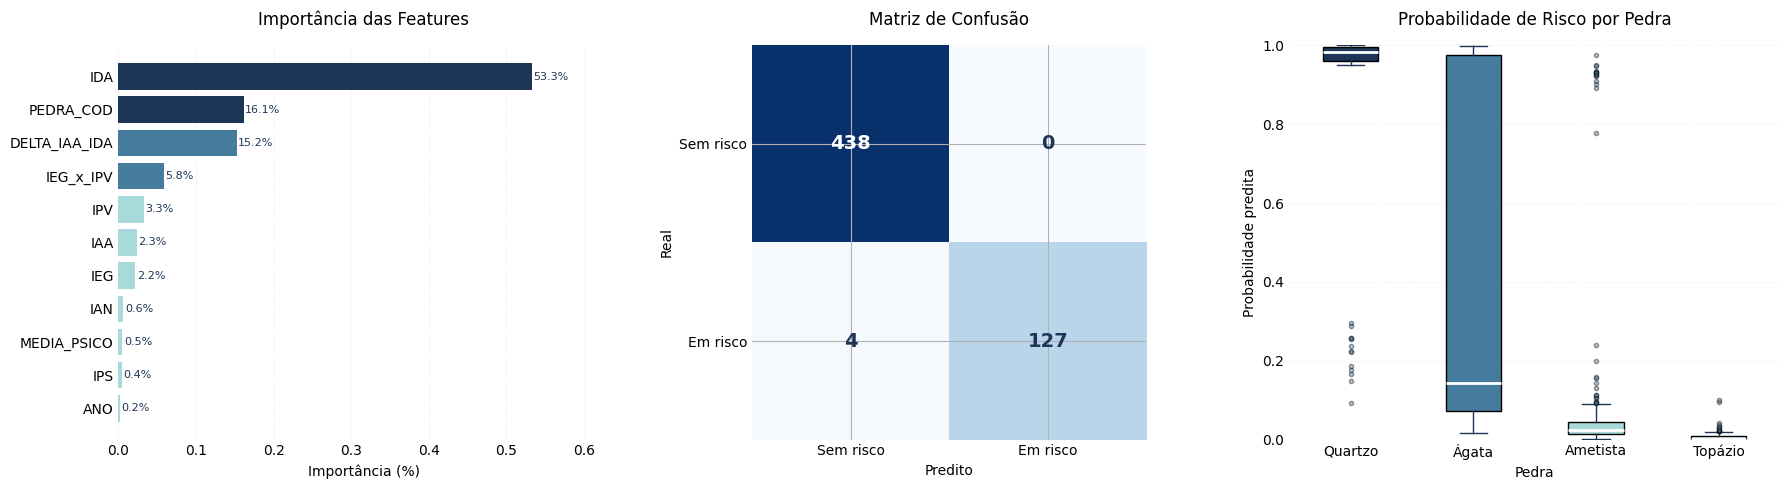

--- Conclusões sobre o Modelo ---

Features mais relevantes:
  IDA                 : 53.3%
  PEDRA_COD           : 16.1%
  DELTA_IAA_IDA       : 15.2%

Falsos negativos (risco não detectado): 4
Taxa de detecção do risco (Recall)    : 96.9%


In [41]:
from sklearn.metrics import ConfusionMatrixDisplay

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Gráfico 1: importância das features
importancias = pd.Series(
    modelo.feature_importances_,
    index=features
).sort_values()

cores_imp = ["#A8DADC" if v < importancias.quantile(0.66) else
             "#457B9D" if v < importancias.quantile(0.90) else
             "#1D3557" for v in importancias.values]

axes[0].barh(importancias.index, importancias.values, color=cores_imp, zorder=3)

for i, (idx, val) in enumerate(importancias.items()):
    axes[0].text(val + 0.002, i, f"{val*100:.1f}%",
                 va="center", fontsize=8, color="#1D3557")

axes[0].set_title("Importância das Features", pad=15)
axes[0].set_xlabel("Importância (%)")
axes[0].set_xlim(0, importancias.max() + 0.10)
axes[0].grid(axis="x", linestyle="--", alpha=0.12, zorder=0)
axes[0].yaxis.grid(False)
for spine in axes[0].spines.values():
    spine.set_visible(False)
axes[0].tick_params(length=0)

# Gráfico 2: matriz de confusão
cm = confusion_matrix(y_test, y_pred)
im = axes[1].imshow(cm, cmap="Blues")

for i in range(2):
    for j in range(2):
        cor = "white" if cm[i, j] > cm.max() / 2 else "#1D3557"
        axes[1].text(j, i, str(cm[i, j]),
                     ha="center", va="center",
                     fontsize=14, color=cor, fontweight="bold")

axes[1].set_xticks([0, 1])
axes[1].set_yticks([0, 1])
axes[1].set_xticklabels(["Sem risco", "Em risco"])
axes[1].set_yticklabels(["Sem risco", "Em risco"])
axes[1].set_xlabel("Predito")
axes[1].set_ylabel("Real")
axes[1].set_title("Matriz de Confusão", pad=15)
for spine in axes[1].spines.values():
    spine.set_visible(False)
axes[1].tick_params(length=0)

# Gráfico 3: distribuição de probabilidade por pedra
pedras_ordem = ["Quartzo", "Ágata", "Ametista", "Topázio"]
cores_pedra  = ["#1D3557", "#457B9D", "#A8DADC", "#E8F4F8"]

df_eval = X_test.copy()
df_eval["PROB_RISCO"] = y_proba

pedra_inv = {0: "Quartzo", 1: "Ágata", 2: "Ametista", 3: "Topázio"}
df_eval["PEDRA_LABEL"] = df_eval["PEDRA_COD"].map(pedra_inv)

dados_box = [
    df_eval[df_eval["PEDRA_LABEL"] == p]["PROB_RISCO"].dropna().values
    for p in pedras_ordem
]

bp = axes[2].boxplot(
    dados_box,
    labels=pedras_ordem,
    patch_artist=True,
    medianprops=dict(color="white", linewidth=2),
    whiskerprops=dict(color="#1D3557"),
    capprops=dict(color="#1D3557"),
    flierprops=dict(marker="o", markersize=3,
                    markerfacecolor="#457B9D", alpha=0.4)
)

for patch, cor in zip(bp["boxes"], cores_pedra):
    patch.set_facecolor(cor)

axes[2].set_title("Probabilidade de Risco por Pedra", pad=15)
axes[2].set_xlabel("Pedra")
axes[2].set_ylabel("Probabilidade predita")
axes[2].set_ylim(0, 1)
axes[2].grid(axis="y", linestyle="--", alpha=0.12, zorder=0)
axes[2].xaxis.grid(False)
for spine in axes[2].spines.values():
    spine.set_visible(False)
axes[2].tick_params(length=0)

plt.tight_layout()
plt.show()

print("--- Conclusões sobre o Modelo ---\n")
top3 = importancias.sort_values(ascending=False).head(3)
print("Features mais relevantes:")
for feat, val in top3.items():
    print(f"  {feat:<20}: {val*100:.1f}%")

falsos_negativos = cm[1, 0]
print(f"\nFalsos negativos (risco não detectado): {falsos_negativos}")
print(f"Taxa de detecção do risco (Recall)    : {recall_score(y_test, y_pred)*100:.1f}%")

### 8.5 Conclusões do modelo preditivo

O modelo Random Forest atingiu ROC-AUC de 99.9%, recall de 96.9% e precisão de 100% — identificando corretamente 127 dos 131 alunos em risco no conjunto de teste, com apenas 4 falsos negativos.

**O que o modelo aprendeu**

O IDA respondeu por 53.3% da importância total, o que é esperado: ele é simultaneamente a feature mais informativa e parte do critério de definição do risco. PEDRA_COD (16.1%) e DELTA_IAA_IDA (15.2%) aparecem em seguida. O delta entre autoavaliação e desempenho real é o achado mais relevante do modelo — alunos que superestimam sua própria situação apresentam padrão de risco distinto, e essa discrepância é capturada como o terceiro sinal mais forte. Indicadores psicossociais (IPS, MEDIA_PSICO) e o ANO contribuíram marginalmente, reforçando que o risco educacional neste dataset é predominantemente explicado por dimensões acadêmicas.

**O que o boxplot de probabilidade revela**

A distribuição por pedra confirma a consistência do modelo: Quartzo concentra probabilidades próximas de 1.0, Ametista e Topázio próximas de 0.0. Ágata apresenta a maior dispersão — é a faixa de transição, onde parte dos alunos ainda está em trajetória de risco e outra parte já consolidou o desenvolvimento, e é exatamente onde intervenções preventivas têm maior potencial de impacto.

**Limitação relevante**

O modelo apresenta desempenho robusto no contexto do Datathon. As métricas elevadas refletem, em parte, vazamento de dados parcial: IDA é ao mesmo tempo feature e critério do target, e PEDRA_COD é derivada do INDE, que por sua vez depende do IDA. Em produção, o redesenho correto seria utilizar os indicadores do ciclo anterior para prever o risco do ciclo seguinte, aproveitando a estrutura longitudinal da base pelo identificador do aluno (RA). Essa abordagem eliminaria o vazamento sem perda de poder preditivo, e é viável com os dados disponíveis.

## 9.Efetividade do Programa

**Os indicadores mostram melhora consistente ao longo do ciclo nas diferentes fases (Quartzo, Ágata, Ametista e Topázio), confirmando o impacto real do programa?**

A análise de efetividade examina se o programa Passos Mágicos produz evolução educacional mensurável ao longo dos ciclos de 2022 a 2024. Para isso, são avaliadas três dimensões: a evolução do INDE médio por classificação de pedra ao longo dos anos, a distribuição dos alunos entre as pedras em cada ciclo, e o comportamento do INDE por fase e ano. Em conjunto, essas análises permitem verificar se os alunos estão progredindo dentro do programa e se o impacto é consistente entre as diferentes classificações.

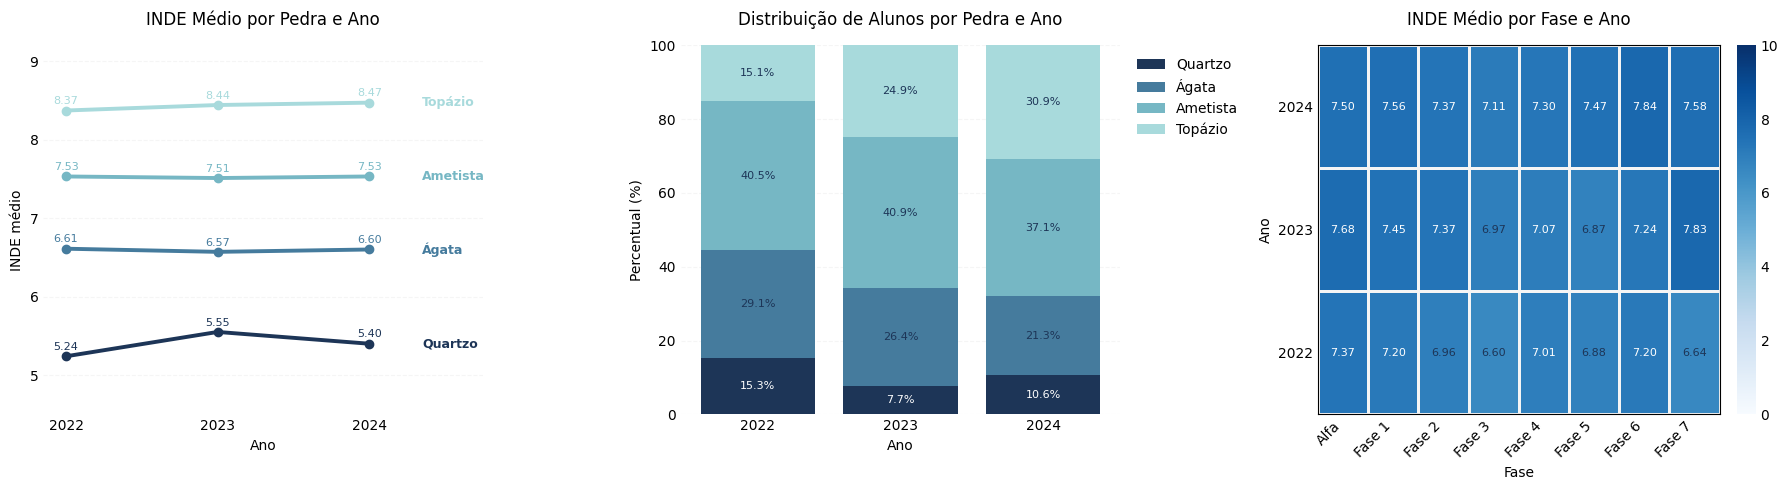

--- INDE Médio por Pedra e Ano ---

PEDRA  Quartzo  Ágata  Ametista  Topázio
ANO                                     
2022      5.24   6.61      7.53     8.37
2023      5.55   6.57      7.51     8.44
2024      5.40   6.60      7.53     8.47

--- Distribuição % por Pedra e Ano ---

PEDRA  Quartzo  Ágata  Ametista  Topázio
ANO                                     
2022     15.30  29.10     40.50    15.10
2023      7.70  26.40     40.90    24.90
2024     10.60  21.30     37.10    30.90


In [42]:
import re

pedras_ordem = ["Quartzo", "Ágata", "Ametista", "Topázio"]
cores_pedra  = ["#1D3557", "#457B9D", "#76B7C4", "#A8DADC"]

df_efet = df_clean[df_clean["PEDRA"].isin(pedras_ordem)].copy()

# Padronização da fase
def extrair_fase(val):
    if pd.isna(val):
        return np.nan

    v = str(val).strip().upper()

    if v == "ALFA":
        return 0

    m = re.search(r"\d+", v)

    return int(m.group()) if m else np.nan


df_efet["FASE_NUM"] = df_efet["Fase"].apply(extrair_fase)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))


# Gráfico 1: evolução do INDE médio por pedra ao longo dos anos
inde_pedra_ano = (
    df_efet.groupby(["ANO", "PEDRA"])["INDE"]
    .mean()
    .round(2)
    .unstack("PEDRA")
    .reindex(columns=pedras_ordem)
)

anos_plot = inde_pedra_ano.index.astype(str)

for pedra, cor in zip(pedras_ordem, cores_pedra):

    axes[0].plot(
        anos_plot,
        inde_pedra_ano[pedra],
        marker="o",
        color=cor,
        linewidth=2.8,
        markersize=6
    )

    for ano, val in inde_pedra_ano[pedra].items():

        axes[0].text(
            str(ano),
            val + 0.08,
            f"{val:.2f}",
            ha="center",
            fontsize=8,
            color=cor
        )

    ultimo_valor = inde_pedra_ano[pedra].iloc[-1]

    axes[0].text(
        len(anos_plot) - 0.65,
        ultimo_valor,
        pedra,
        va="center",
        fontsize=9,
        color=cor,
        fontweight="bold"
    )

axes[0].set_title("INDE Médio por Pedra e Ano", pad=15)
axes[0].set_xlabel("Ano")
axes[0].set_ylabel("INDE médio")
axes[0].set_ylim(4.5, 9.2)
axes[0].set_xlim(-0.15, len(anos_plot) - 0.25)

axes[0].grid(
    axis="y",
    linestyle="--",
    alpha=0.12,
    zorder=0
)

axes[0].xaxis.grid(False)

for spine in axes[0].spines.values():
    spine.set_visible(False)

axes[0].tick_params(length=0)


# Gráfico 2: distribuição de alunos por pedra e ano
dist_pedra = (
    df_efet.groupby(["ANO", "PEDRA"])
    .size()
    .unstack(fill_value=0)
    .reindex(columns=pedras_ordem)
)

dist_pedra_pct = (
    dist_pedra
    .div(dist_pedra.sum(axis=1), axis=0) * 100
)

bottom = np.zeros(len(dist_pedra_pct))
anos_str = dist_pedra_pct.index.astype(str)

for pedra, cor in zip(pedras_ordem, cores_pedra):

    vals = dist_pedra_pct[pedra].values

    axes[1].bar(
        anos_str,
        vals,
        bottom=bottom,
        color=cor,
        label=pedra,
        zorder=3
    )

    for i, (v, b) in enumerate(zip(vals, bottom)):

        if v > 4:

            axes[1].text(
                i,
                b + v / 2,
                f"{v:.1f}%",
                ha="center",
                va="center",
                fontsize=8,
                color="white" if cor == "#1D3557" else "#1D3557"
            )

    bottom += vals

axes[1].set_title("Distribuição de Alunos por Pedra e Ano", pad=15)
axes[1].set_xlabel("Ano")
axes[1].set_ylabel("Percentual (%)")
axes[1].set_ylim(0, 100)

axes[1].legend(
    frameon=False,
    loc="upper left",
    bbox_to_anchor=(1.01, 1)
)

axes[1].grid(
    axis="y",
    linestyle="--",
    alpha=0.12,
    zorder=0
)

axes[1].xaxis.grid(False)

for spine in axes[1].spines.values():
    spine.set_visible(False)

axes[1].tick_params(length=0)


# Gráfico 3: heatmap INDE médio por fase e ano
inde_fase_ano = (
    df_efet.groupby(["ANO", "FASE_NUM"])["INDE"]
    .mean()
    .round(2)
    .unstack("FASE_NUM")
)

inde_fase_ano = inde_fase_ano.reindex(
    columns=sorted(inde_fase_ano.columns)
)

im = axes[2].pcolormesh(
    inde_fase_ano.values,
    cmap="Blues",
    vmin=0,
    vmax=10,
    edgecolors="#F5F5F5",
    linewidth=2
)

for i in range(len(inde_fase_ano.index)):

    for j in range(len(inde_fase_ano.columns)):

        val = inde_fase_ano.iloc[i, j]

        if not np.isnan(val):

            cor_txt = "white" if val >= 7 else "#1D3557"

            axes[2].text(
                j + 0.5,
                i + 0.5,
                f"{val:.2f}",
                ha="center",
                va="center",
                fontsize=8,
                color=cor_txt
            )

axes[2].set_xticks(np.arange(len(inde_fase_ano.columns)) + 0.5)
axes[2].set_yticks(np.arange(len(inde_fase_ano.index)) + 0.5)

axes[2].set_xticklabels(
    [f"Fase {int(f)}" if f != 0 else "Alfa" for f in inde_fase_ano.columns],
    rotation=45,
    ha="right"
)

axes[2].set_yticklabels(inde_fase_ano.index.astype(str))
axes[2].set_title("INDE Médio por Fase e Ano", pad=15)
axes[2].set_xlabel("Fase")
axes[2].set_ylabel("Ano")
axes[2].tick_params(length=0)
axes[2].grid(False)

cbar = plt.colorbar(
    im,
    ax=axes[2],
    fraction=0.046,
    pad=0.04
)

cbar.outline.set_visible(False)
cbar.ax.tick_params(length=0)

plt.tight_layout()
plt.show()

print("--- INDE Médio por Pedra e Ano ---\n")
print(inde_pedra_ano.to_string())

print("\n--- Distribuição % por Pedra e Ano ---\n")
print(dist_pedra_pct.round(1).to_string())

### 9.1 Conclusões sobre a efetividade do programa

Os dados confirmam o impacto real do programa Passos Mágicos ao longo dos ciclos analisados.

A evidência mais direta está na migração entre classificações: a proporção de alunos Quartzo — a faixa de maior vulnerabilidade — caiu de 15.3% em 2022 para 7.7% em 2023, com leve recomposição para 10.6% em 2024, possivelmente associada à entrada de novos alunos. No sentido oposto, Topázio cresceu de 15.1% para 30.9% no mesmo período, dobrando a participação dos alunos no nível mais avançado em apenas dois ciclos.

O INDE médio por pedra permanece estável entre os anos, o que indica que as faixas de classificação estão bem calibradas e que o avanço dos alunos se expressa pela migração entre pedras, não pelo crescimento dentro de uma mesma faixa. Esse é o comportamento esperado de um programa com critérios de progressão bem definidos.

O heatmap por fase reforça a consistência do programa: nenhuma fase apresenta queda sistemática de INDE ao longo dos anos, e o desempenho é distribuído de forma relativamente uniforme entre os níveis de aprendizado, evidenciando que o impacto do programa não está concentrado em uma faixa etária ou de desenvolvimento específica.

## 10.Exportação para Streamlit

Com o modelo treinado e avaliado, esta etapa realiza a serialização dos artefatos necessários para o deploy da aplicação preditiva. O modelo Random Forest e a lista de features são exportados via joblib e devem ser incluídos no repositório GitHub junto ao app Streamlit para disponibilização no Community Cloud.

In [43]:
import joblib

# Serialização do modelo e das features
joblib.dump(modelo, "modelo.joblib")
joblib.dump(features, "features.joblib")

print("Artefatos exportados:")
print("  modelo.joblib")
print("  features.joblib")

Artefatos exportados:
  modelo.joblib
  features.joblib
